In [1]:
import pandas as pd
import numpy as np

from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [2]:
import os
print(os.getcwd())

/Users/raresolteanu


In [3]:
os.chdir("/Users/raresolteanu/Desktop/WC-2026")
print(os.getcwd())

/Users/raresolteanu/Desktop/WC-2026


In [4]:
full_df = pd.read_csv("datasets/wc_2026_training_table_clean_with_spi_and_odds.csv")
spi_df = pd.read_csv("datasets/wc_2026_spi_experiment_model_table.csv")
odds_df = pd.read_csv("datasets/wc_2026_odds_experiment_model_table.csv")
schedule_2026 = pd.read_csv("datasets/WC 2026 match schedule advanced.csv")

In [5]:
for name, df in {
    "full_df": full_df,
    "spi_df": spi_df,
    "odds_df": odds_df,
    "schedule_2026": schedule_2026,
}.items():
    print(name, df.shape)

full_df (30696, 140)
spi_df (3860, 140)
odds_df (1080, 140)
schedule_2026 (104, 60)


Convert dates:

In [6]:
for df in [full_df, spi_df, odds_df, schedule_2026]:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [7]:
datasets = {
    "full_df": full_df,
    "spi_df": spi_df,
    "odds_df": odds_df,
    "schedule_2026": schedule_2026,
}

summary = []

for name, df in datasets.items():
    summary.append({
        "dataset": name,
        "rows": len(df),
        "columns": df.shape[1],
        "start_date": df["date"].min(),
        "end_date": df["date"].max(),
        "duplicate_matches": df.duplicated(["date", "home_team", "away_team"]).sum()
            if {"date", "home_team", "away_team"}.issubset(df.columns)
            else None,
    })

display(pd.DataFrame(summary))

,dataset,rows,columns,start_date,end_date,duplicate_matches
0,full_df,30696,140,1993-01-01,2026-06-10,0
1,spi_df,3860,140,2019-01-02,2024-01-25,0
2,odds_df,1080,140,2014-06-12,2026-03-31,0
3,schedule_2026,104,60,2026-06-11,2026-07-19,0


## Dataset Roles

`full_df` is the full historical dataset and is used for baseline modeling.

`spi_df` contains only matches with verified SPI features and is used for the SPI experiment track.

`odds_df` contains only matches with verified historical betting odds and is used for the odds experiment track.

`schedule_2026` contains future World Cup 2026 fixtures and is used only for prediction, not model training.

## 2. Define Leakage Rules

Before training, we remove columns that would not be known before kickoff. These include final scores, goal differences, result labels, and post-match statistics. The model should only use information available before the match.

In [8]:
leakage_cols = [
    "home_score",
    "away_score",
    "goal_diff",
    "total_goals",
    "home_score_capped",
    "away_score_capped",
    "is_extreme_scoreline",
    "result",
    "result_encoded",
]

metadata_cols = [
    "date",
    "home_team",
    "away_team",
    "tournament",
    "city",
    "country",
    "stadium",
    "kickoff_time_local",
    "timezone",
    "group",
    "match_stage_status",
    "is_placeholder_match",
]

post_match_spi_cols = [
    "score1",
    "score2",
    "xg1",
    "xg2",
    "nsxg1",
    "nsxg2",
    "adj_score1",
    "adj_score2",
]

forbidden_cols = set(leakage_cols + metadata_cols + post_match_spi_cols)

In [9]:
def check_forbidden_columns(df, name):
    found = sorted([col for col in forbidden_cols if col in df.columns])
    print(f"{name}: {len(found)} forbidden/non-feature columns found")
    print(found)

check_forbidden_columns(full_df, "full_df")
check_forbidden_columns(spi_df, "spi_df")
check_forbidden_columns(odds_df, "odds_df")
check_forbidden_columns(schedule_2026, "schedule_2026")

full_df: 14 forbidden/non-feature columns found
['away_score', 'away_score_capped', 'away_team', 'city', 'country', 'date', 'goal_diff', 'home_score', 'home_score_capped', 'home_team', 'is_extreme_scoreline', 'result', 'total_goals', 'tournament']
spi_df: 14 forbidden/non-feature columns found
['away_score', 'away_score_capped', 'away_team', 'city', 'country', 'date', 'goal_diff', 'home_score', 'home_score_capped', 'home_team', 'is_extreme_scoreline', 'result', 'total_goals', 'tournament']
odds_df: 14 forbidden/non-feature columns found
['away_score', 'away_score_capped', 'away_team', 'city', 'country', 'date', 'goal_diff', 'home_score', 'home_score_capped', 'home_team', 'is_extreme_scoreline', 'result', 'total_goals', 'tournament']
schedule_2026: 11 forbidden/non-feature columns found
['away_team', 'city', 'country', 'date', 'group', 'home_team', 'is_placeholder_match', 'kickoff_time_local', 'match_stage_status', 'stadium', 'timezone']


In [10]:
def assert_no_leakage_features(features, name):
    bad_features = sorted([col for col in features if col in forbidden_cols])

    if bad_features:
        raise ValueError(f"{name} contains leakage/metadata columns: {bad_features}")

    print(f"{name}: no forbidden features")

## 3. Final Dataset EDA

Before training, we inspect the final modeling datasets. The goal is to check target balance, date coverage, missing values, odds/SPI coverage and whether the strongest predictive columns behave logically.

In [11]:
def target_balance(df, name):
    balance = (
        df["result"]
        .value_counts()
        .rename_axis("result")
        .reset_index(name="count")
    )

    balance["share"] = (balance["count"] / len(df)).round(4)
    balance["dataset"] = name

    return balance

In [12]:
def missing_summary(df, name, top_n=20):
    missing = (
        df.isna()
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )

    missing.columns = ["column", "missing_rows"]
    missing["missing_share"] = (missing["missing_rows"] / len(df)).round(4)
    missing["dataset"] = name

    return missing[missing["missing_rows"] > 0].head(top_n)

In [13]:
def rows_by_year(df, name):
    temp = df.copy()
    temp["year"] = temp["date"].dt.year

    yearly = (
        temp.groupby("year")
        .size()
        .reset_index(name="rows")
    )

    yearly["dataset"] = name
    return yearly

In [14]:
display(target_balance(full_df, "full_df"))
display(target_balance(spi_df, "spi_df"))
display(target_balance(odds_df, "odds_df"))

,result,count,share,dataset
0,home_win,14905,0.4856,full_df
1,away_win,8634,0.2813,full_df
2,draw,7157,0.2332,full_df


,result,count,share,dataset
0,home_win,1872,0.4850,spi_df
1,away_win,1133,0.2935,spi_df
2,draw,855,0.2215,spi_df


,result,count,share,dataset
0,home_win,496,0.4593,odds_df
1,away_win,345,0.3194,odds_df
2,draw,239,0.2213,odds_df


They are more baalnced in the odds group

In [15]:
display(missing_summary(full_df, "full_df"))
display(missing_summary(spi_df, "spi_df"))
display(missing_summary(odds_df, "odds_df"))
display(missing_summary(schedule_2026, "schedule_2026"))

,column,missing_rows,missing_share,dataset
0,home_spi_importance,3844,0.1252,full_df
1,away_spi_importance,3844,0.1252,full_df
2,spi_importance_diff,3844,0.1252,full_df
3,fifa_rank_diff,2683,0.0874,full_df
4,fifa_points_zscore_diff,2683,0.0874,full_df
5,fifa_points_percentile_by_date_y,2156,0.0702,full_df
6,away_fifa_points,2156,0.0702,full_df
7,away_fifa_rank,2156,0.0702,full_df
8,away_fifa_points_zscore,2156,0.0702,full_df
9,teams_in_ranking_date_y,2156,0.0702,full_df


,column,missing_rows,missing_share,dataset
0,home_spi_importance,3844,0.9959,spi_df
1,away_spi_importance,3844,0.9959,spi_df
2,spi_importance_diff,3844,0.9959,spi_df
3,fifa_rank_diff,76,0.0197,spi_df
4,fifa_points_zscore_diff,76,0.0197,spi_df
5,fifa_points_percentile_by_date_y,44,0.0114,spi_df
6,away_fifa_points,44,0.0114,spi_df
7,away_fifa_rank,44,0.0114,spi_df
8,away_fifa_points_zscore,44,0.0114,spi_df
9,teams_in_ranking_date_y,44,0.0114,spi_df


,column,missing_rows,missing_share,dataset
0,spi_importance_diff,48,0.0444,odds_df
1,away_spi_importance,48,0.0444,odds_df
2,home_spi_importance,48,0.0444,odds_df


,column,missing_rows,missing_share,dataset
0,home_attack_rating,32,0.3077,schedule_2026
1,away_xg_against_rolling,32,0.3077,schedule_2026
2,defense_rating_diff,32,0.3077,schedule_2026
3,attack_rating_diff,32,0.3077,schedule_2026
4,strength_rating_diff,32,0.3077,schedule_2026
5,home_xg_for_rolling,32,0.3077,schedule_2026
6,home_xg_against_rolling,32,0.3077,schedule_2026
7,away_xg_for_rolling,32,0.3077,schedule_2026
8,xg_attack_diff,32,0.3077,schedule_2026
9,xg_defense_diff,32,0.3077,schedule_2026


The SPI importance columns are almost entirely missing, especially in the SPI experiment table. They are excluded from modeling because they do not provide reliable coverage.

In [16]:
known_schedule = schedule_2026[
    schedule_2026["is_placeholder_match"] == False
].copy()

placeholder_schedule = schedule_2026[
    schedule_2026["is_placeholder_match"] == True
].copy()

print(known_schedule.shape)
print(placeholder_schedule.shape)

(72, 60)
(32, 60)


### Missing Value Notes
FIFA ranking differences have some missing values, especially in the full historical dataset. These are handled with missing-value indicator columns and by filling the missing differences with 0.

The odds experiment dataset has strong coverage for the odds features and is safe for the odds modeling track.

The 2026 schedule has missing advanced features for some rows, likely because several knockout-stage fixtures are placeholders where teams are not known yet. These rows should not be predicted until the teams are known, or they should be handled separately.

In [17]:
full_model = full_df.copy()
spi_model = spi_df.copy()
odds_model = odds_df.copy()
schedule_model = schedule_2026.copy()

Drop the useless SPI importance columns:

In [18]:
useless_cols = [
    "home_spi_importance",
    "away_spi_importance",
    "spi_importance_diff",
]

for df in [full_model, spi_model, odds_model, schedule_model]:
    cols_to_drop = [col for col in useless_cols if col in df.columns]
    df.drop(columns=cols_to_drop, inplace=True)

Fill FIFA missingness with indicators:

In [19]:
for df in [full_model, spi_model, odds_model, schedule_model]:
    if "fifa_rank_diff" in df.columns:
        df["missing_fifa_rank"] = df["fifa_rank_diff"].isna().astype(int)
        df["fifa_rank_diff"] = df["fifa_rank_diff"].fillna(0)

    if "fifa_points_zscore_diff" in df.columns:
        df["missing_fifa_points_zscore"] = df["fifa_points_zscore_diff"].isna().astype(int)
        df["fifa_points_zscore_diff"] = df["fifa_points_zscore_diff"].fillna(0)

In [20]:
advanced_schedule_cols = [
    "home_xg_for_rolling",
    "home_xg_against_rolling",
    "away_xg_for_rolling",
    "away_xg_against_rolling",
    "xg_attack_diff",
    "xg_defense_diff",
    "xg_balance_diff",
    "home_overall_rating",
    "home_attack_rating",
    "home_defense_rating",
    "away_overall_rating",
    "away_attack_rating",
    "away_defense_rating",
    "strength_rating_diff",
    "attack_rating_diff",
    "defense_rating_diff",
]

existing_advanced_schedule_cols = [
    col for col in advanced_schedule_cols
    if col in schedule_model.columns
]

schedule_model["missing_advanced_team_features"] = (
    schedule_model[existing_advanced_schedule_cols]
    .isna()
    .any(axis=1)
    .astype(int)
)

schedule_model[existing_advanced_schedule_cols] = (
    schedule_model[existing_advanced_schedule_cols]
    .fillna(0)
)

In [21]:
def missing_summary_selected(df, columns, name):
    existing_cols = [col for col in columns if col in df.columns]

    missing = (
        df[existing_cols]
        .isna()
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )

    missing.columns = ["column", "missing_rows"]
    missing["missing_share"] = (missing["missing_rows"] / len(df)).round(4)
    missing["dataset"] = name

    return missing[missing["missing_rows"] > 0]

In [22]:
important_check_cols = [
    "fifa_rank_diff",
    "fifa_points_zscore_diff",
    "missing_fifa_rank",
    "missing_fifa_points_zscore",
    "market_home_prob_norm",
    "market_draw_prob_norm",
    "market_away_prob_norm",
    "odds_prob_diff",
    "market_favorite_prob",
    "market_draw_prob",
    "home_spi_prob",
    "draw_spi_prob",
    "away_spi_prob",
    "spi_prob_diff",
] + advanced_schedule_cols

display(missing_summary_selected(full_model, important_check_cols, "full_model"))
display(missing_summary_selected(spi_model, important_check_cols, "spi_model"))
display(missing_summary_selected(odds_model, important_check_cols, "odds_model"))
display(missing_summary_selected(schedule_model, important_check_cols, "schedule_model"))

,column,missing_rows,missing_share,dataset


,column,missing_rows,missing_share,dataset


,column,missing_rows,missing_share,dataset


,column,missing_rows,missing_share,dataset


In [23]:
for name, df in {
    "full_model": full_model,
    "spi_model": spi_model,
    "odds_model": odds_model,
    "schedule_model": schedule_model,
}.items():
    remaining = [col for col in useless_cols if col in df.columns]
    print(name, "remaining useless columns:", remaining)

full_model remaining useless columns: []
spi_model remaining useless columns: []
odds_model remaining useless columns: []
schedule_model remaining useless columns: []


In [24]:
display(rows_by_year(full_df, "full_df"))
display(rows_by_year(spi_df, "spi_df"))
display(rows_by_year(odds_df, "odds_df"))

,year,rows,dataset
0,1993,795,full_df
1,1994,609,full_df
2,1995,669,full_df
3,1996,837,full_df
4,1997,907,full_df
5,1998,761,full_df
6,1999,776,full_df
7,2000,1040,full_df
8,2001,1032,full_df
9,2002,768,full_df


,year,rows,dataset
0,2019,1001,spi_df
1,2020,312,spi_df
2,2021,1057,spi_df
3,2022,933,spi_df
4,2023,521,spi_df
5,2024,36,spi_df


,year,rows,dataset
0,2014,64,odds_df
1,2018,64,odds_df
2,2022,64,odds_df
3,2023,136,odds_df
4,2024,246,odds_df
5,2025,490,odds_df
6,2026,16,odds_df


In [25]:
odds_model_trainable = odds_model[
    (odds_model["date"] < "2026-01-01") &
    (odds_model["result"].notna())
].copy()

print(odds_model_trainable.shape)
display(rows_by_year(odds_model_trainable, "odds_model_trainable"))

(1064, 139)


,year,rows,dataset
0,2014,64,odds_model_trainable
1,2018,64,odds_model_trainable
2,2022,64,odds_model_trainable
3,2023,136,odds_model_trainable
4,2024,246,odds_model_trainable
5,2025,490,odds_model_trainable


The odds dataset is concentrated in a few tournament years and recent qualification matches. To avoid leakage into the 2026 prediction year, all 2026 rows are excluded from model training and validation.

The final odds experiment uses a strict chronological split:
- training: matches before 2024
- validation: 2024 matches
- test: 2025 matches

The 2025 test set is kept untouched until final evaluation.

In [26]:
import matplotlib.pyplot as plt

def plot_target_balance(df, name):
    counts = df["result"].value_counts(normalize=True)

    plt.figure(figsize=(7, 4))
    counts.plot(kind="bar")
    plt.title(f"Target Balance - {name}")
    plt.xlabel("Result")
    plt.ylabel("Share")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

In [27]:
def plot_rows_by_year(df, name):
    yearly = df.groupby(df["date"].dt.year).size()

    plt.figure(figsize=(10, 4))
    yearly.plot()
    plt.title(f"Rows by Year - {name}")
    plt.xlabel("Year")
    plt.ylabel("Rows")
    plt.grid(alpha=0.3)
    plt.show()


In [28]:
def plot_hist(df, column, title=None, bins=30):
    plt.figure(figsize=(8, 4))
    df[column].dropna().hist(bins=bins)
    plt.title(title or f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.grid(alpha=0.3)
    plt.show()

In [29]:
def plot_scatter(df, x, y, title=None, alpha=0.35):
    plt.figure(figsize=(7, 5))
    plt.scatter(df[x], df[y], alpha=alpha)
    plt.title(title or f"{x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.grid(alpha=0.3)
    plt.show()

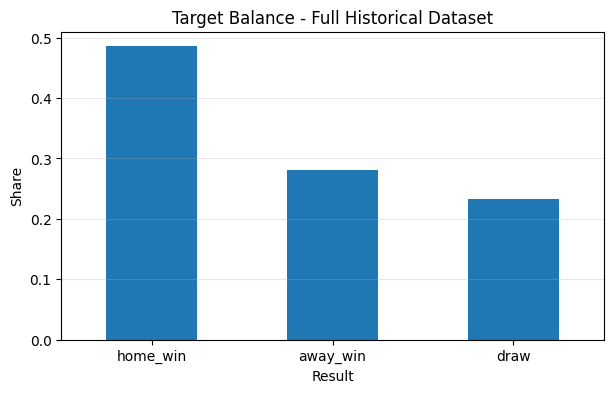

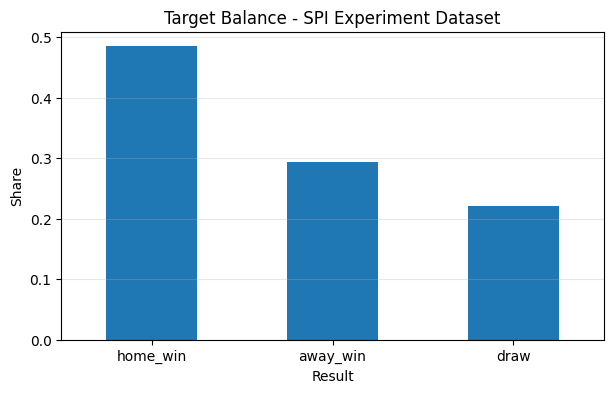

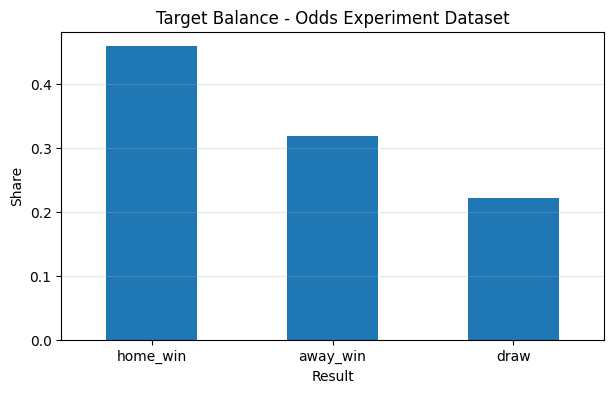

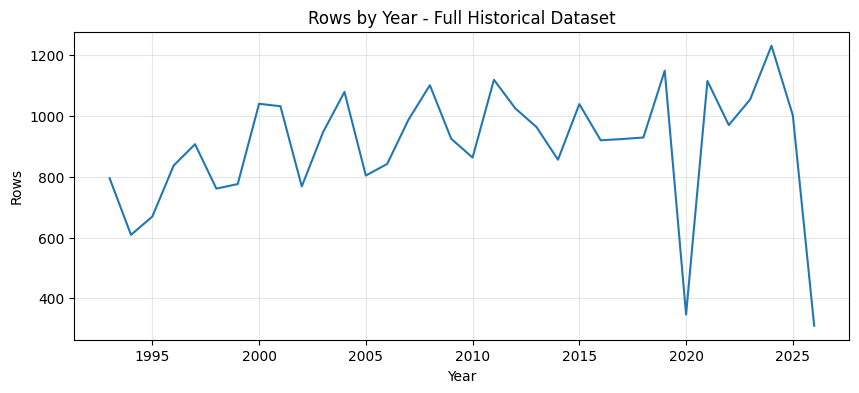

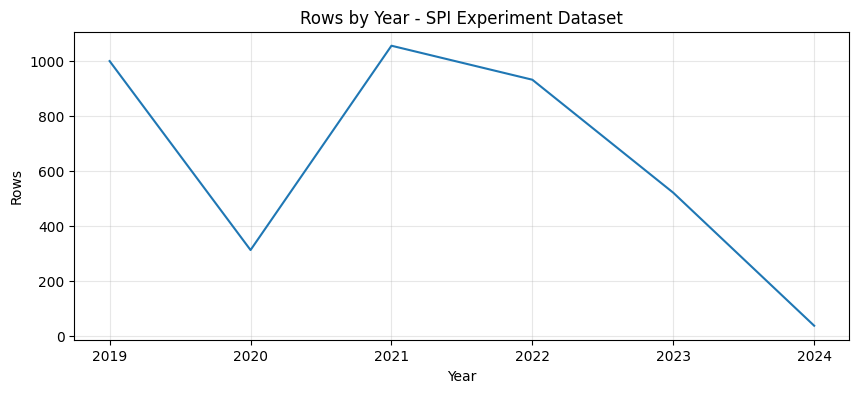

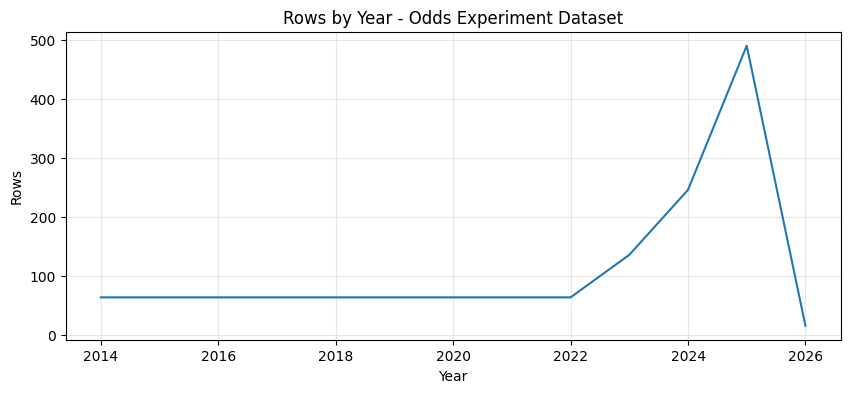

In [30]:
plot_target_balance(full_df, "Full Historical Dataset")
plot_target_balance(spi_df, "SPI Experiment Dataset")
plot_target_balance(odds_df, "Odds Experiment Dataset")

plot_rows_by_year(full_df, "Full Historical Dataset")
plot_rows_by_year(spi_df, "SPI Experiment Dataset")
plot_rows_by_year(odds_df, "Odds Experiment Dataset")

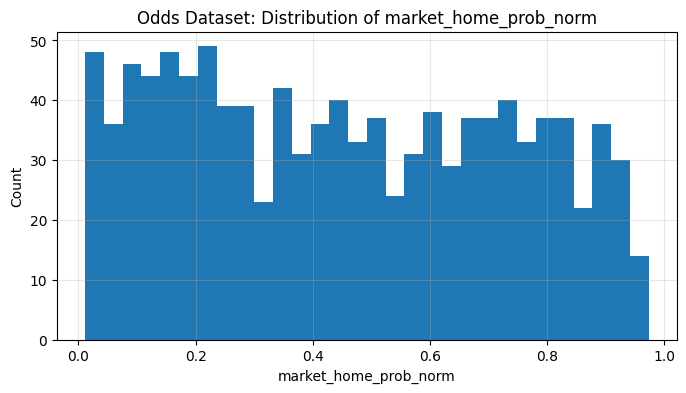

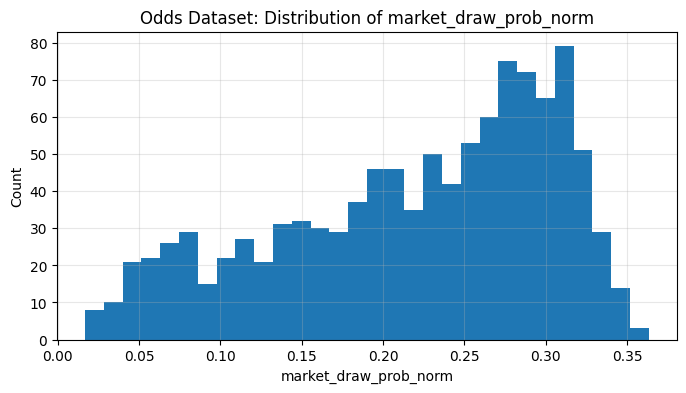

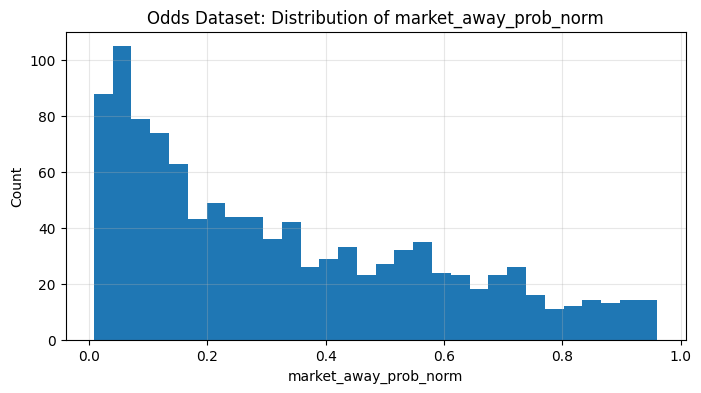

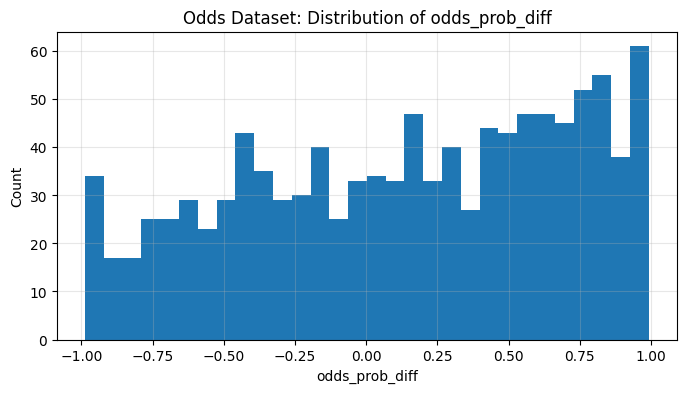

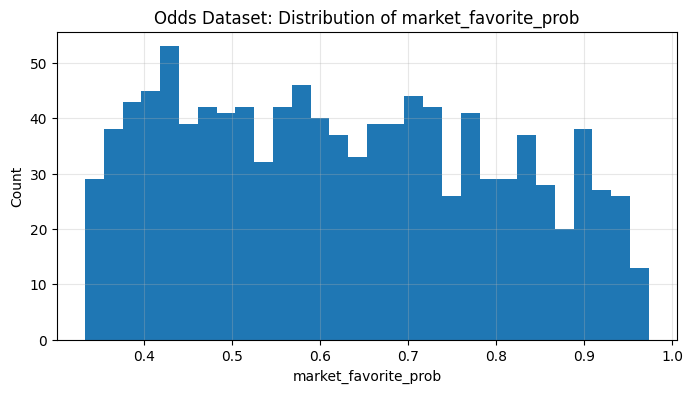

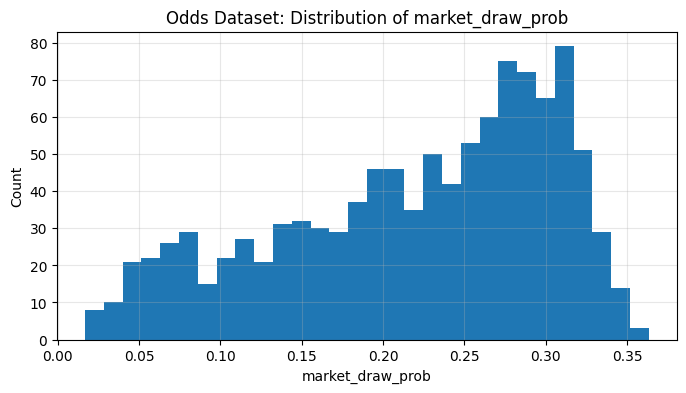

In [31]:
odds_cols = [
    "market_home_prob_norm",
    "market_draw_prob_norm",
    "market_away_prob_norm",
    "odds_prob_diff",
    "market_favorite_prob",
    "market_draw_prob",
]

for col in odds_cols:
    plot_hist(odds_df, col, title=f"Odds Dataset: Distribution of {col}")

### Odds Feature Distribution Notes

The market probability features have realistic distributions. Draw probability is concentrated around typical football draw ranges, while home and away probabilities cover a broad range of favorite and underdog cases.

The `odds_prob_diff` feature captures the direction and strength of the market favorite. Positive values favor the home team, negative values favor the away team and values near 0 indicate a close matchup.

Because the normalized market probabilities sum to 1, they are suitable for modeling. These normalized probabilities are preferred over raw implied probabilities because raw odds include bookmaker margin.

In [32]:
odds_df["market_prob_sum"] = (
    odds_df["market_home_prob_norm"] +
    odds_df["market_draw_prob_norm"] +
    odds_df["market_away_prob_norm"]
)

display(odds_df["market_prob_sum"].describe())

bad_market_prob_rows = odds_df[
    ~odds_df["market_prob_sum"].between(0.99, 1.01)
]

print("Bad market probability rows:", len(bad_market_prob_rows))

count    1.080000e+03
mean     1.000000e+00
std      1.241382e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: market_prob_sum, dtype: float64

Bad market probability rows: 0


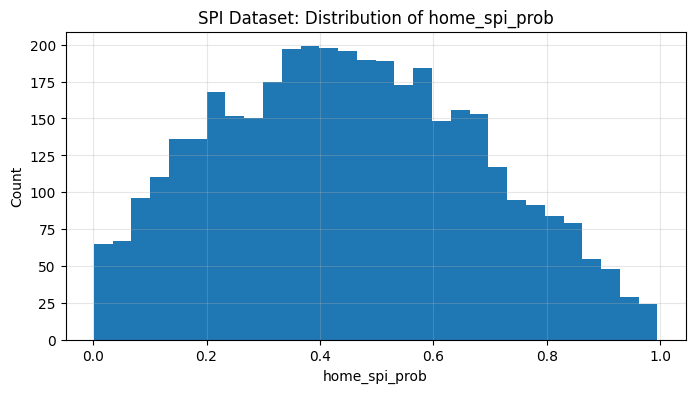

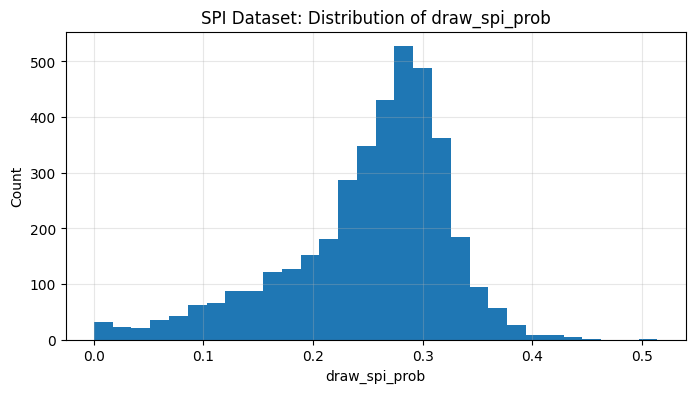

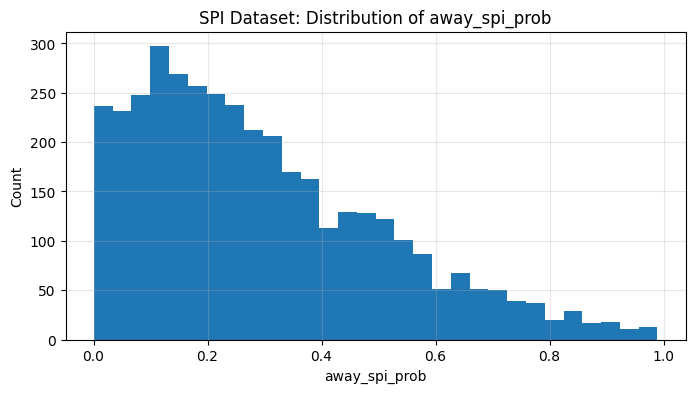

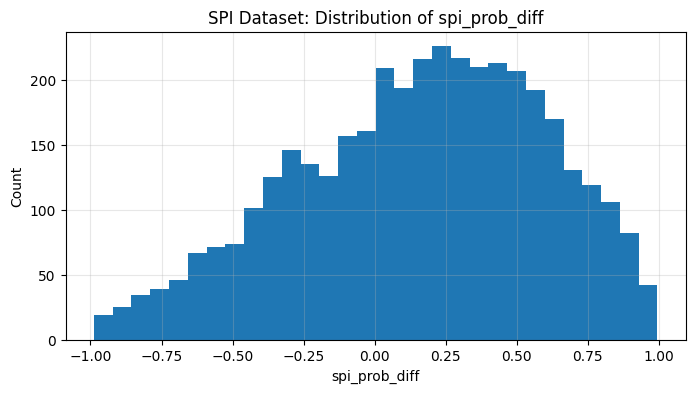

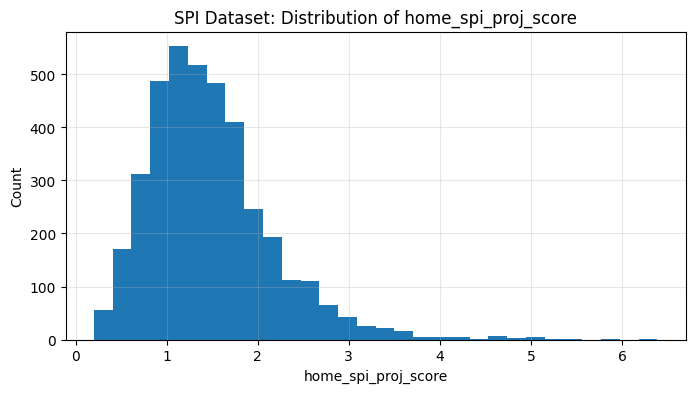

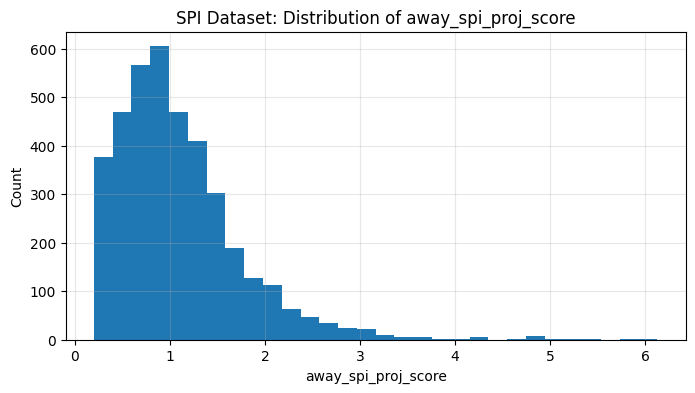

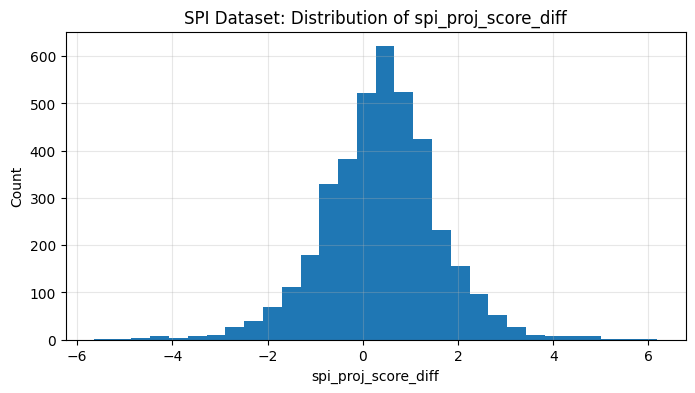

In [33]:
spi_cols = [
    "home_spi_prob",
    "draw_spi_prob",
    "away_spi_prob",
    "spi_prob_diff",
    "home_spi_proj_score",
    "away_spi_proj_score",
    "spi_proj_score_diff",
]

for col in spi_cols:
    if col in spi_df.columns:
        plot_hist(spi_df, col, title=f"SPI Dataset: Distribution of {col}")

In [34]:
spi_model["spi_prob_sum"] = (
    spi_model["home_spi_prob"] +
    spi_model["draw_spi_prob"] +
    spi_model["away_spi_prob"]
)

display(spi_model["spi_prob_sum"].describe())

bad_spi_prob_rows = spi_model[
    ~spi_model["spi_prob_sum"].between(0.99, 1.01)
]

print("Bad SPI probability rows:", len(bad_spi_prob_rows))

display(
    bad_spi_prob_rows[
        ["date", "home_team", "away_team", "spi_prob_sum"]
    ].head()
)

count    3860.000000
mean        0.999999
std         0.000050
min         0.999900
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000100
Name: spi_prob_sum, dtype: float64

Bad SPI probability rows: 0


,date,home_team,away_team,spi_prob_sum


### SPI Feature Distribution Notes

The SPI probability features are valid and well distributed. The draw probability is concentrated in a realistic football range, while the home and away win probabilities cover both favorite and underdog cases.

The `spi_prob_diff` feature captures the direction and strength of the SPI favorite. Positive values favor the home team, negative values favor the away team, and values close to 0 indicate a balanced matchup.

Projected score features are right-skewed, which is expected because football goals are low-count outcomes. These SPI features are safe to use only inside the SPI experiment dataset where verified SPI match data exists.

In [35]:
def result_rate_by_bins(df, feature, bins=5):
    temp = df[[feature, "result"]].dropna().copy()
    temp["bin"] = pd.qcut(temp[feature], q=bins, duplicates="drop")

    rates = (
        temp
        .groupby("bin", observed=False)["result"]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .round(3)
    )

    return rates

In [36]:
display(result_rate_by_bins(odds_df, "odds_prob_diff"))
display(result_rate_by_bins(odds_df, "market_favorite_prob"))
display(result_rate_by_bins(spi_df, "spi_prob_diff"))

result,away_win,draw,home_win
bin,,,
"(-0.988, -0.437]",0.773,0.148,0.079
"(-0.437, -0.00267]",0.421,0.343,0.236
"(-0.00267, 0.396]",0.292,0.287,0.421
"(0.396, 0.706]",0.097,0.255,0.648
"(0.706, 0.992]",0.014,0.074,0.912


result,away_win,draw,home_win
bin,,,
"(0.332, 0.445]",0.361,0.306,0.333
"(0.445, 0.561]",0.338,0.315,0.347
"(0.561, 0.679]",0.319,0.250,0.431
"(0.679, 0.803]",0.287,0.181,0.532
"(0.803, 0.974]",0.292,0.056,0.653


result,away_win,draw,home_win
bin,,,
"(-0.989, -0.246]",0.693,0.189,0.118
"(-0.246, 0.0726]",0.396,0.271,0.333
"(0.0726, 0.311]",0.207,0.289,0.504
"(0.311, 0.554]",0.127,0.249,0.624
"(0.554, 0.995]",0.044,0.110,0.846


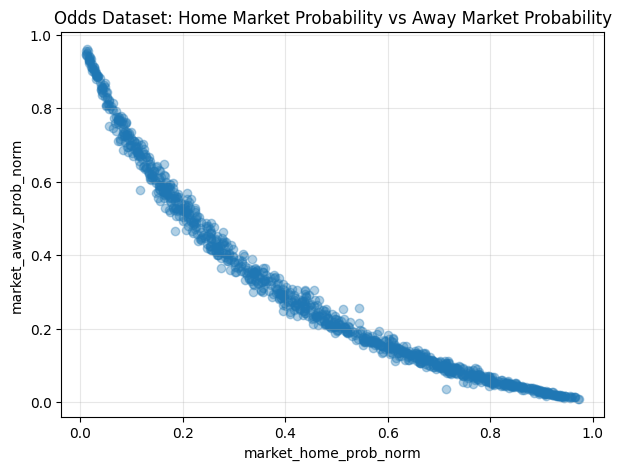

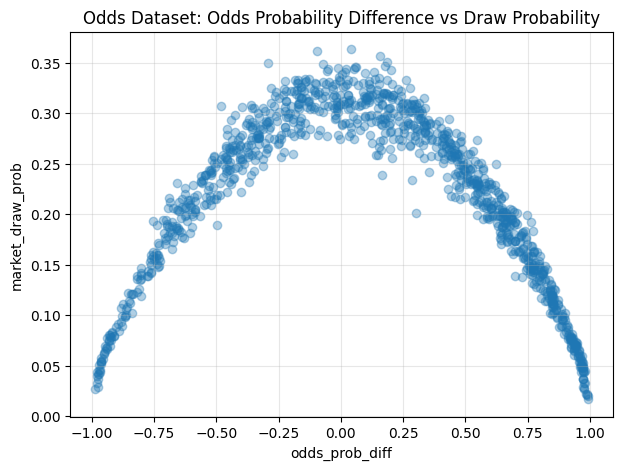

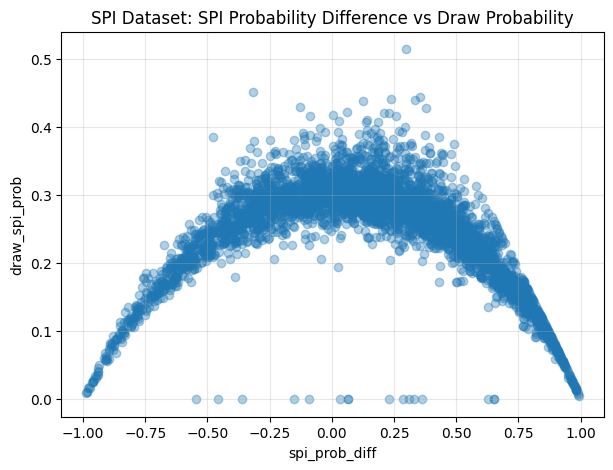

In [37]:
plot_scatter(
    odds_df,
    "market_home_prob_norm",
    "market_away_prob_norm",
    title="Odds Dataset: Home Market Probability vs Away Market Probability"
)

plot_scatter(
    odds_df,
    "odds_prob_diff",
    "market_draw_prob",
    title="Odds Dataset: Odds Probability Difference vs Draw Probability"
)

plot_scatter(
    spi_df,
    "spi_prob_diff",
    "draw_spi_prob",
    title="SPI Dataset: SPI Probability Difference vs Draw Probability"
)

In [38]:
import seaborn as sns

def plot_corr_heatmap(df, columns, title):
    corr = df[columns].corr()

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

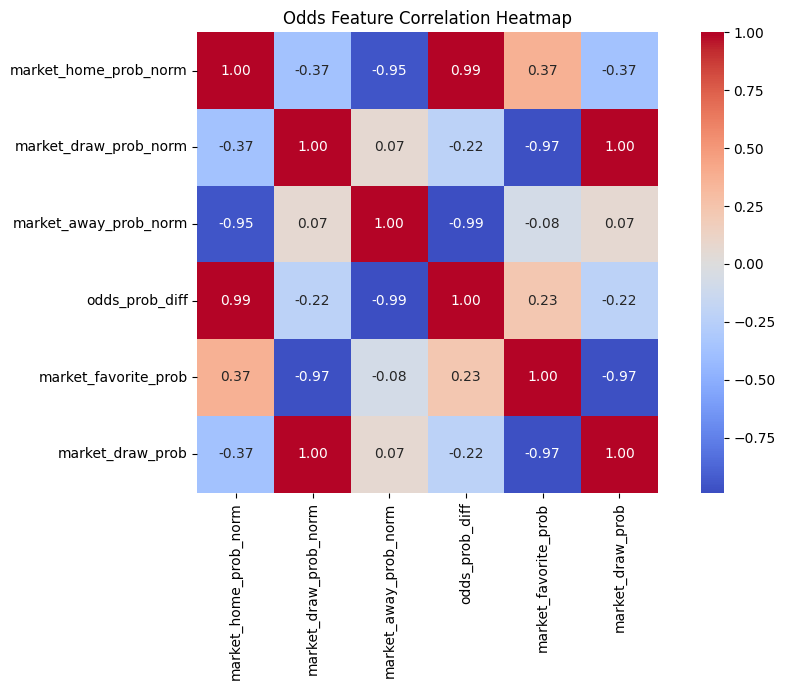

In [39]:
odds_corr_cols = [
    "market_home_prob_norm",
    "market_draw_prob_norm",
    "market_away_prob_norm",
    "odds_prob_diff",
    "market_favorite_prob",
    "market_draw_prob",
]

plot_corr_heatmap(
    odds_model,
    odds_corr_cols,
    "Odds Feature Correlation Heatmap"
)

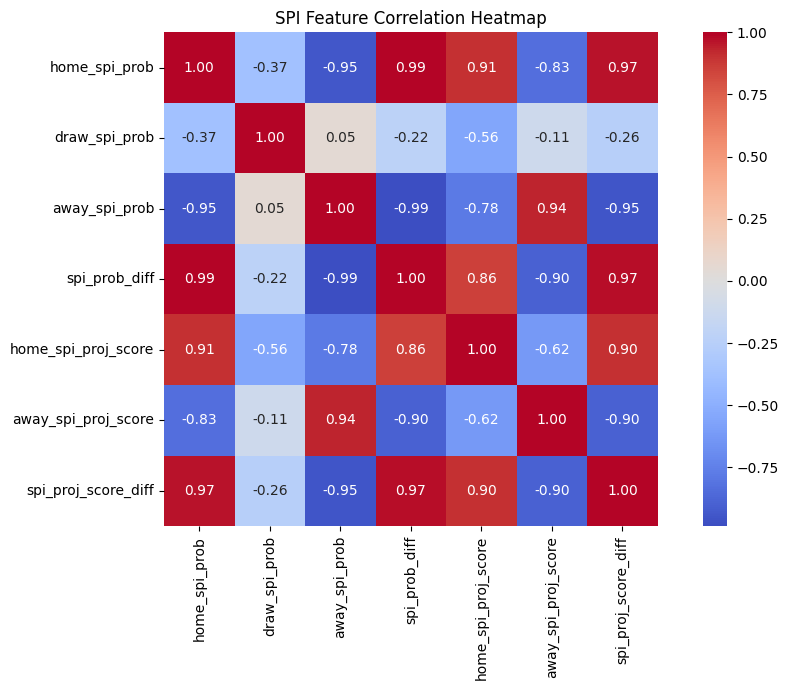

In [40]:
spi_corr_cols = [
    "home_spi_prob",
    "draw_spi_prob",
    "away_spi_prob",
    "spi_prob_diff",
    "home_spi_proj_score",
    "away_spi_proj_score",
    "spi_proj_score_diff",
]

plot_corr_heatmap(
    spi_model,
    spi_corr_cols,
    "SPI Feature Correlation Heatmap"
)

### Correlation Notes

The odds and SPI features are highly correlated because many of them are different transformations of the same underlying probabilities.

For Logistic Regression, compact feature sets are preferred to reduce redundancy and make coefficients easier to interpret.

For tree-based models such as XGBoost, the fuller feature sets can still be tested because tree models are less sensitive to multicollinearity.

In [41]:
def plot_result_rate_by_bins(df, feature, title, bins=5):
    rates = result_rate_by_bins(df, feature, bins=bins)

    rates.plot(kind="bar", figsize=(9, 5))
    plt.title(title)
    plt.xlabel(feature)
    plt.ylabel("Result share")
    plt.xticks(rotation=35, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    display(rates)

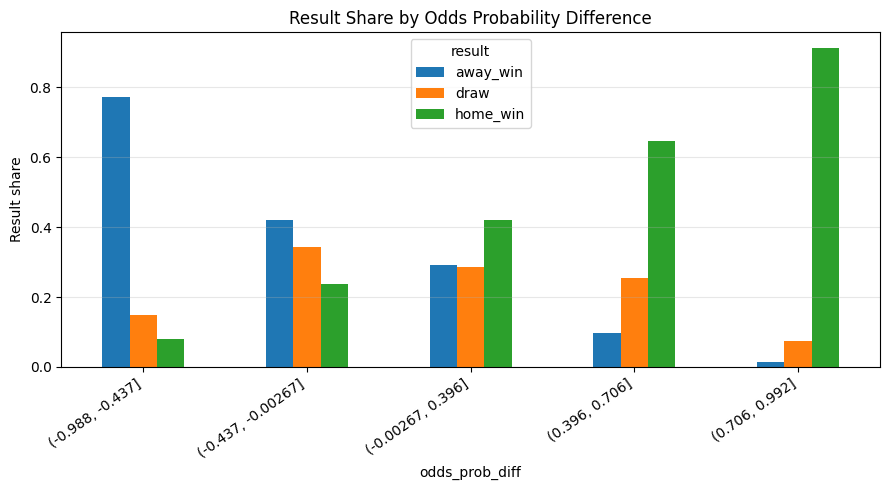

result,away_win,draw,home_win
bin,,,
"(-0.988, -0.437]",0.773,0.148,0.079
"(-0.437, -0.00267]",0.421,0.343,0.236
"(-0.00267, 0.396]",0.292,0.287,0.421
"(0.396, 0.706]",0.097,0.255,0.648
"(0.706, 0.992]",0.014,0.074,0.912


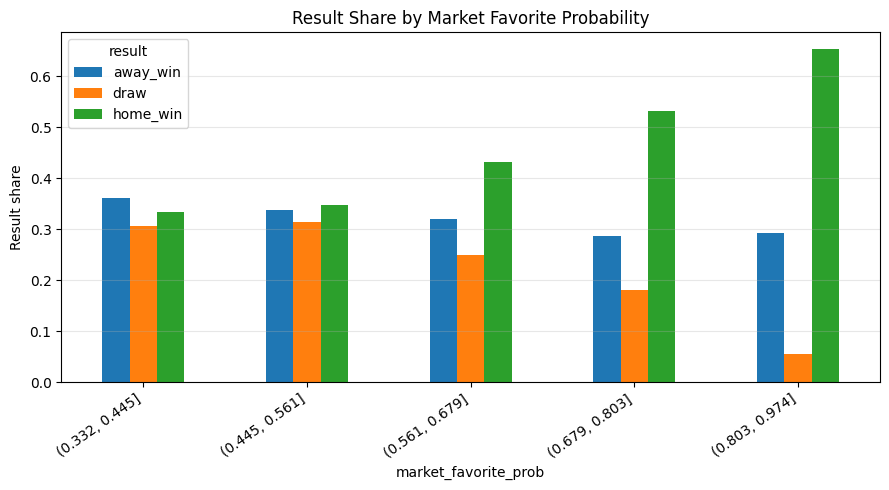

result,away_win,draw,home_win
bin,,,
"(0.332, 0.445]",0.361,0.306,0.333
"(0.445, 0.561]",0.338,0.315,0.347
"(0.561, 0.679]",0.319,0.250,0.431
"(0.679, 0.803]",0.287,0.181,0.532
"(0.803, 0.974]",0.292,0.056,0.653


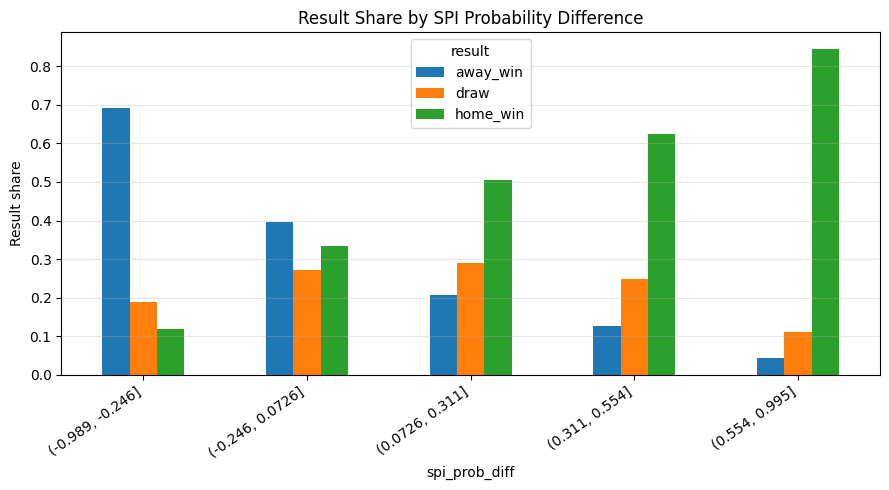

result,away_win,draw,home_win
bin,,,
"(-0.989, -0.246]",0.693,0.189,0.118
"(-0.246, 0.0726]",0.396,0.271,0.333
"(0.0726, 0.311]",0.207,0.289,0.504
"(0.311, 0.554]",0.127,0.249,0.624
"(0.554, 0.995]",0.044,0.110,0.846


In [42]:
plot_result_rate_by_bins(
    odds_model,
    "odds_prob_diff",
    "Result Share by Odds Probability Difference"
)

plot_result_rate_by_bins(
    odds_model,
    "market_favorite_prob",
    "Result Share by Market Favorite Probability"
)

plot_result_rate_by_bins(
    spi_model,
    "spi_prob_diff",
    "Result Share by SPI Probability Difference"
)

## 4. Prepare Feature Sets

We create separate feature sets for each modeling track. The baseline model uses historical team-strength and match-context features. The SPI model uses verified SPI features. The odds model uses verified pre-match market odds features.

After defining each feature list, we check that no leakage or metadata columns are included.

In [43]:
baseline_features = [
    "elo_diff",
    "fifa_rank_diff",
    "fifa_points_zscore_diff",
    "form_score_5_diff",
    "form_score_10_diff",
    "form_trend_diff",
    "attack_diff",
    "defense_diff",
    "rest_days_diff",
    "neutral",
    "is_home_country",
    "is_home_confed",
    "is_away_confed",
    "missing_fifa_rank",
    "missing_fifa_points_zscore",
]

spi_compact_features = [
    "spi_prob_diff",
    "draw_spi_prob",
]

spi_full_features = [
    "home_spi_prob",
    "draw_spi_prob",
    "away_spi_prob",
    "spi_prob_diff",
    "home_spi_proj_score",
    "away_spi_proj_score",
    "spi_proj_score_diff",
]

odds_compact_features = [
    "odds_prob_diff",
    "market_draw_prob",
    "market_favorite_prob",
]

odds_prob_features = [
    "market_home_prob_norm",
    "market_draw_prob_norm",
    "market_away_prob_norm",
]

odds_full_features = list(dict.fromkeys(
    odds_compact_features + baseline_features
))

In [44]:
def check_feature_columns(df, features, name):
    missing = [col for col in features if col not in df.columns]

    if missing:
        raise ValueError(f"{name} missing columns: {missing}")

    print(f"{name}: all {len(features)} features exist")


check_feature_columns(full_model, baseline_features, "baseline_features")
check_feature_columns(spi_model, spi_compact_features, "spi_compact_features")
check_feature_columns(spi_model, spi_full_features, "spi_full_features")
check_feature_columns(odds_model_trainable, odds_compact_features, "odds_compact_features")
check_feature_columns(odds_model_trainable, odds_prob_features, "odds_prob_features")
check_feature_columns(odds_model_trainable, odds_full_features, "odds_full_features")

baseline_features: all 15 features exist
spi_compact_features: all 2 features exist
spi_full_features: all 7 features exist
odds_compact_features: all 3 features exist
odds_prob_features: all 3 features exist
odds_full_features: all 18 features exist


In [45]:
assert_no_leakage_features(baseline_features, "baseline_features")
assert_no_leakage_features(spi_compact_features, "spi_compact_features")
assert_no_leakage_features(spi_full_features, "spi_full_features")
assert_no_leakage_features(odds_compact_features, "odds_compact_features")
assert_no_leakage_features(odds_prob_features, "odds_prob_features")
assert_no_leakage_features(odds_full_features, "odds_full_features")

baseline_features: no forbidden features
spi_compact_features: no forbidden features
spi_full_features: no forbidden features
odds_compact_features: no forbidden features
odds_prob_features: no forbidden features
odds_full_features: no forbidden features


## 5. Time-Based Train Validation Test Split

Full Historical Split

In [46]:
full_trainable = full_model[
    (full_model["date"] < "2026-01-01") &
    (full_model["result"].notna())
].copy()

full_train = full_trainable[full_trainable["date"] < "2019-01-01"].copy()

full_val = full_trainable[
    (full_trainable["date"] >= "2019-01-01") &
    (full_trainable["date"] < "2023-01-01")
].copy()

full_test = full_trainable[
    (full_trainable["date"] >= "2023-01-01") &
    (full_trainable["date"] < "2026-01-01")
].copy()

print("Full train:", full_train.shape, full_train["date"].min(), full_train["date"].max())
print("Full val:", full_val.shape, full_val["date"].min(), full_val["date"].max())
print("Full test:", full_test.shape, full_test["date"].min(), full_test["date"].max())

Full train: (23518, 139) 1993-01-01 00:00:00 2018-12-31 00:00:00
Full val: (3581, 139) 2019-01-02 00:00:00 2022-12-30 00:00:00
Full test: (3287, 139) 2023-01-02 00:00:00 2025-12-31 00:00:00


SPI Split

In [47]:
spi_trainable = spi_model[
    (spi_model["date"] < "2026-01-01") &
    (spi_model["result"].notna())
].copy()

spi_train = spi_trainable[spi_trainable["date"] < "2022-01-01"].copy()

spi_val = spi_trainable[
    (spi_trainable["date"] >= "2022-01-01") &
    (spi_trainable["date"] < "2023-01-01")
].copy()

spi_test = spi_trainable[
    (spi_trainable["date"] >= "2023-01-01") &
    (spi_trainable["date"] < "2026-01-01")
].copy()

print("SPI train:", spi_train.shape, spi_train["date"].min(), spi_train["date"].max())
print("SPI val:", spi_val.shape, spi_val["date"].min(), spi_val["date"].max())
print("SPI test:", spi_test.shape, spi_test["date"].min(), spi_test["date"].max())

SPI train: (2370, 140) 2019-01-02 00:00:00 2021-12-31 00:00:00
SPI val: (933, 140) 2022-01-01 00:00:00 2022-12-30 00:00:00
SPI test: (557, 140) 2023-01-02 00:00:00 2024-01-25 00:00:00


Odds Split

In [48]:
odds_trainable = odds_model_trainable.copy()

odds_train = odds_trainable[odds_trainable["date"] < "2024-01-01"].copy()

odds_val = odds_trainable[
    (odds_trainable["date"] >= "2024-01-01") &
    (odds_trainable["date"] < "2025-01-01")
].copy()

odds_test = odds_trainable[
    (odds_trainable["date"] >= "2025-01-01") &
    (odds_trainable["date"] < "2026-01-01")
].copy()

print("Odds train:", odds_train.shape, odds_train["date"].min(), odds_train["date"].max())
print("Odds val:", odds_val.shape, odds_val["date"].min(), odds_val["date"].max())
print("Odds test:", odds_test.shape, odds_test["date"].min(), odds_test["date"].max())

Odds train: (328, 139) 2014-06-12 00:00:00 2023-11-21 00:00:00
Odds val: (246, 139) 2024-03-21 00:00:00 2024-11-19 00:00:00
Odds test: (490, 139) 2025-03-19 00:00:00 2025-11-18 00:00:00


In [49]:
display(target_balance(full_train, "full_train"))
display(target_balance(full_val, "full_val"))
display(target_balance(full_test, "full_test"))

display(target_balance(spi_train, "spi_train"))
display(target_balance(spi_val, "spi_val"))
display(target_balance(spi_test, "spi_test"))

display(target_balance(odds_train, "odds_train"))
display(target_balance(odds_val, "odds_val"))
display(target_balance(odds_test, "odds_test"))

,result,count,share,dataset
0,home_win,11465,0.4875,full_train
1,away_win,6531,0.2777,full_train
2,draw,5522,0.2348,full_train


,result,count,share,dataset
0,home_win,1741,0.4862,full_val
1,away_win,1032,0.2882,full_val
2,draw,808,0.2256,full_val


,result,count,share,dataset
0,home_win,1546,0.4703,full_test
1,away_win,991,0.3015,full_test
2,draw,750,0.2282,full_test


,result,count,share,dataset
0,home_win,1146,0.4835,spi_train
1,away_win,694,0.2928,spi_train
2,draw,530,0.2236,spi_train


,result,count,share,dataset
0,home_win,471,0.5048,spi_val
1,away_win,253,0.2712,spi_val
2,draw,209,0.2240,spi_val


,result,count,share,dataset
0,home_win,255,0.4578,spi_test
1,away_win,186,0.3339,spi_test
2,draw,116,0.2083,spi_test


,result,count,share,dataset
0,home_win,140,0.4268,odds_train
1,away_win,115,0.3506,odds_train
2,draw,73,0.2226,odds_train


,result,count,share,dataset
0,home_win,112,0.4553,odds_val
1,away_win,72,0.2927,odds_val
2,draw,62,0.2520,odds_val


,result,count,share,dataset
0,home_win,236,0.4816,odds_test
1,away_win,154,0.3143,odds_test
2,draw,100,0.2041,odds_test


The data is split chronologically to prevent future information from leaking into training. Each modeling track has its own split because the available date ranges differ across the full historical, SPI, and odds datasets.

## 6. Create X and y Matrices

In [50]:
X_full_train = full_train[baseline_features]
X_full_val = full_val[baseline_features]
X_full_test = full_test[baseline_features]

y_full_train = full_train["result"]
y_full_val = full_val["result"]
y_full_test = full_test["result"]


X_spi_train_compact = spi_train[spi_compact_features]
X_spi_val_compact = spi_val[spi_compact_features]
X_spi_test_compact = spi_test[spi_compact_features]

X_spi_train_full = spi_train[spi_full_features]
X_spi_val_full = spi_val[spi_full_features]
X_spi_test_full = spi_test[spi_full_features]

y_spi_train = spi_train["result"]
y_spi_val = spi_val["result"]
y_spi_test = spi_test["result"]


X_odds_train_compact = odds_train[odds_compact_features]
X_odds_val_compact = odds_val[odds_compact_features]
X_odds_test_compact = odds_test[odds_compact_features]

X_odds_train_prob = odds_train[odds_prob_features]
X_odds_val_prob = odds_val[odds_prob_features]
X_odds_test_prob = odds_test[odds_prob_features]

X_odds_train_full = odds_train[odds_full_features]
X_odds_val_full = odds_val[odds_full_features]
X_odds_test_full = odds_test[odds_full_features]

y_odds_train = odds_train["result"]
y_odds_val = odds_val["result"]
y_odds_test = odds_test["result"]

In [51]:
shape_summary = pd.DataFrame([
    {"dataset": "full_train", "X_shape": X_full_train.shape, "y_len": len(y_full_train)},
    {"dataset": "full_val", "X_shape": X_full_val.shape, "y_len": len(y_full_val)},
    {"dataset": "full_test", "X_shape": X_full_test.shape, "y_len": len(y_full_test)},

    {"dataset": "spi_train_compact", "X_shape": X_spi_train_compact.shape, "y_len": len(y_spi_train)},
    {"dataset": "spi_val_compact", "X_shape": X_spi_val_compact.shape, "y_len": len(y_spi_val)},
    {"dataset": "spi_test_compact", "X_shape": X_spi_test_compact.shape, "y_len": len(y_spi_test)},

    {"dataset": "odds_train_compact", "X_shape": X_odds_train_compact.shape, "y_len": len(y_odds_train)},
    {"dataset": "odds_val_compact", "X_shape": X_odds_val_compact.shape, "y_len": len(y_odds_val)},
    {"dataset": "odds_test_compact", "X_shape": X_odds_test_compact.shape, "y_len": len(y_odds_test)},
])

display(shape_summary)

,dataset,X_shape,y_len
0,full_train,"(23518, 15)",23518
1,full_val,"(3581, 15)",3581
2,full_test,"(3287, 15)",3287
3,spi_train_compact,"(2370, 2)",2370
4,spi_val_compact,"(933, 2)",933
5,spi_test_compact,"(557, 2)",557
6,odds_train_compact,"(328, 3)",328
7,odds_val_compact,"(246, 3)",246
8,odds_test_compact,"(490, 3)",490


In [52]:
model_matrices = {
    "X_full_train": X_full_train,
    "X_full_val": X_full_val,
    "X_full_test": X_full_test,

    "X_spi_train_compact": X_spi_train_compact,
    "X_spi_val_compact": X_spi_val_compact,
    "X_spi_test_compact": X_spi_test_compact,
    "X_spi_train_full": X_spi_train_full,
    "X_spi_val_full": X_spi_val_full,
    "X_spi_test_full": X_spi_test_full,

    "X_odds_train_compact": X_odds_train_compact,
    "X_odds_val_compact": X_odds_val_compact,
    "X_odds_test_compact": X_odds_test_compact,
    "X_odds_train_prob": X_odds_train_prob,
    "X_odds_val_prob": X_odds_val_prob,
    "X_odds_test_prob": X_odds_test_prob,
    "X_odds_train_full": X_odds_train_full,
    "X_odds_val_full": X_odds_val_full,
    "X_odds_test_full": X_odds_test_full,
}

for name, X in model_matrices.items():
    missing = X.isna().sum().sum()
    print(name, "missing values:", missing)

X_full_train missing values: 0
X_full_val missing values: 0
X_full_test missing values: 0
X_spi_train_compact missing values: 0
X_spi_val_compact missing values: 0
X_spi_test_compact missing values: 0
X_spi_train_full missing values: 0
X_spi_val_full missing values: 0
X_spi_test_full missing values: 0
X_odds_train_compact missing values: 0
X_odds_val_compact missing values: 0
X_odds_test_compact missing values: 0
X_odds_train_prob missing values: 0
X_odds_val_prob missing values: 0
X_odds_test_prob missing values: 0
X_odds_train_full missing values: 0
X_odds_val_full missing values: 0
X_odds_test_full missing values: 0


## 7. Final Leakage Checks Before Modeling

Before fitting any model, we verify that the feature matrices do not contain target columns, score columns, metadata columns, or future-only fields. We also check date ordering and duplicate match keys.

In [53]:
feature_sets = {
    "baseline_features": baseline_features,
    "spi_compact_features": spi_compact_features,
    "spi_full_features": spi_full_features,
    "odds_compact_features": odds_compact_features,
    "odds_prob_features": odds_prob_features,
    "odds_full_features": odds_full_features,
}

for name, features in feature_sets.items():
    assert_no_leakage_features(features, name)

baseline_features: no forbidden features
spi_compact_features: no forbidden features
spi_full_features: no forbidden features
odds_compact_features: no forbidden features
odds_prob_features: no forbidden features
odds_full_features: no forbidden features


In [54]:
suspicious_patterns = [
    "score",
    "goal_diff",
    "total_goals",
    "result",
    "winner",
    "xg1",
    "xg2",
    "nsxg",
    "adj_score",
]

for name, features in feature_sets.items():
    suspicious = [
        col for col in features
        if any(pattern in col.lower() for pattern in suspicious_patterns)
    ]

    print(name, suspicious)

baseline_features ['fifa_points_zscore_diff', 'form_score_5_diff', 'form_score_10_diff', 'missing_fifa_points_zscore']
spi_compact_features []
spi_full_features ['home_spi_proj_score', 'away_spi_proj_score', 'spi_proj_score_diff']
odds_compact_features []
odds_prob_features []
odds_full_features ['fifa_points_zscore_diff', 'form_score_5_diff', 'form_score_10_diff', 'missing_fifa_points_zscore']


The suspicious-name check flagged several columns containing the word `score`, but these are not leakage columns. `form_score_*` features are pre-match rolling form metrics, `fifa_points_zscore_diff` is a pre-match ranking feature and `spi_proj_score_*` features are pre-match SPI projected scores. None of these use the final match result.

In [55]:
def check_split_dates(train, val, test, name):
    print(f"\n{name}")
    print("train:", train["date"].min(), "to", train["date"].max(), "rows:", len(train))
    print("val:", val["date"].min(), "to", val["date"].max(), "rows:", len(val))
    print("test:", test["date"].min(), "to", test["date"].max(), "rows:", len(test))

    assert train["date"].max() < val["date"].min(), f"{name}: train/val date overlap"
    assert val["date"].max() < test["date"].min(), f"{name}: val/test date overlap"

    print("Date ordering OK")


check_split_dates(full_train, full_val, full_test, "Full Historical")
check_split_dates(spi_train, spi_val, spi_test, "SPI")
check_split_dates(odds_train, odds_val, odds_test, "Odds")


Full Historical
train: 1993-01-01 00:00:00 to 2018-12-31 00:00:00 rows: 23518
val: 2019-01-02 00:00:00 to 2022-12-30 00:00:00 rows: 3581
test: 2023-01-02 00:00:00 to 2025-12-31 00:00:00 rows: 3287
Date ordering OK

SPI
train: 2019-01-02 00:00:00 to 2021-12-31 00:00:00 rows: 2370
val: 2022-01-01 00:00:00 to 2022-12-30 00:00:00 rows: 933
test: 2023-01-02 00:00:00 to 2024-01-25 00:00:00 rows: 557
Date ordering OK

Odds
train: 2014-06-12 00:00:00 to 2023-11-21 00:00:00 rows: 328
val: 2024-03-21 00:00:00 to 2024-11-19 00:00:00 rows: 246
test: 2025-03-19 00:00:00 to 2025-11-18 00:00:00 rows: 490
Date ordering OK


In [56]:
def check_split_key_overlap(train, val, test, name):
    key_cols = ["date", "home_team", "away_team"]

    train_keys = set(map(tuple, train[key_cols].values))
    val_keys = set(map(tuple, val[key_cols].values))
    test_keys = set(map(tuple, test[key_cols].values))

    print(f"\n{name}")
    print("train-val overlap:", len(train_keys & val_keys))
    print("train-test overlap:", len(train_keys & test_keys))
    print("val-test overlap:", len(val_keys & test_keys))

    assert len(train_keys & val_keys) == 0
    assert len(train_keys & test_keys) == 0
    assert len(val_keys & test_keys) == 0

    print("Key overlap OK")


check_split_key_overlap(full_train, full_val, full_test, "Full Historical")
check_split_key_overlap(spi_train, spi_val, spi_test, "SPI")
check_split_key_overlap(odds_train, odds_val, odds_test, "Odds")


Full Historical
train-val overlap: 0
train-test overlap: 0
val-test overlap: 0
Key overlap OK

SPI
train-val overlap: 0
train-test overlap: 0
val-test overlap: 0
Key overlap OK

Odds
train-val overlap: 0
train-test overlap: 0
val-test overlap: 0
Key overlap OK


In [57]:
for name, df in {
    "full_train": full_train,
    "full_val": full_val,
    "full_test": full_test,
    "spi_train": spi_train,
    "spi_val": spi_val,
    "spi_test": spi_test,
    "odds_train": odds_train,
    "odds_val": odds_val,
    "odds_test": odds_test,
}.items():
    max_date = df["date"].max()
    print(name, max_date)

    assert max_date < pd.Timestamp("2026-01-01"), f"{name} contains 2026 rows"

full_train 2018-12-31 00:00:00
full_val 2022-12-30 00:00:00
full_test 2025-12-31 00:00:00
spi_train 2021-12-31 00:00:00
spi_val 2022-12-30 00:00:00
spi_test 2024-01-25 00:00:00
odds_train 2023-11-21 00:00:00
odds_val 2024-11-19 00:00:00
odds_test 2025-11-18 00:00:00


In [58]:
for name, X in model_matrices.items():
    bad_cols = [col for col in X.columns if col in forbidden_cols]

    print(name, bad_cols)

    assert bad_cols == [], f"{name} contains forbidden columns: {bad_cols}"

X_full_train []
X_full_val []
X_full_test []
X_spi_train_compact []
X_spi_val_compact []
X_spi_test_compact []
X_spi_train_full []
X_spi_val_full []
X_spi_test_full []
X_odds_train_compact []
X_odds_val_compact []
X_odds_test_compact []
X_odds_train_prob []
X_odds_val_prob []
X_odds_test_prob []
X_odds_train_full []
X_odds_val_full []
X_odds_test_full []


### Final Leakage Check Result

All modeling tracks passed the leakage checks.

The train, validation and test splits are chronological with no date overlap. There are no duplicate match keys across splits and all 2026 rows are excluded from training, validation and testing. The feature matrices do not contain forbidden columns such as final scores, result labels, goal differences, match identifiers, or metadata fields.

The suspicious-name check flagged some pre-match features containing the word `score`, but these are valid because they represent pre-match form scores, FIFA z-scores, or SPI projected scores rather than final match outcomes.

## 8. Baseline Models

In [59]:
def evaluate_classifier(model, X, y, name):
    preds = model.predict(X)

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X)
        loss = log_loss(y, probs, labels=model.classes_)
    else:
        loss = None

    print(name)
    print("Accuracy:", round(accuracy_score(y, preds), 4))
    print("Balanced accuracy:", round(balanced_accuracy_score(y, preds), 4))
    print("Macro F1:", round(f1_score(y, preds, average="macro"), 4))
    print("Weighted F1:", round(f1_score(y, preds, average="weighted"), 4))

    if loss is not None:
        print("Log loss:", round(loss, 4))

    print("\nClassification report:")
    print(classification_report(y, preds))

    print("Confusion matrix:")
    print(confusion_matrix(y, preds, labels=model.classes_))

In [60]:
dummy_full_prior = DummyClassifier(strategy="prior")
dummy_full_prior.fit(X_full_train, y_full_train)

evaluate_classifier(
    dummy_full_prior,
    X_full_val,
    y_full_val,
    "Prior Dummy Baseline - Full Historical"
)

Prior Dummy Baseline - Full Historical
Accuracy: 0.4862
Balanced accuracy: 0.3333
Macro F1: 0.2181
Weighted F1: 0.3181
Log loss: 1.0455

Classification report:
              precision    recall  f1-score   support

    away_win       0.00      0.00      0.00      1032
        draw       0.00      0.00      0.00       808
    home_win       0.49      1.00      0.65      1741

    accuracy                           0.49      3581
   macro avg       0.16      0.33      0.22      3581
weighted avg       0.24      0.49      0.32      3581

Confusion matrix:
[[   0    0 1032]
 [   0    0  808]
 [   0    0 1741]]


In [61]:
dummy_spi_prior = DummyClassifier(strategy="prior")
dummy_spi_prior.fit(X_spi_train_compact, y_spi_train)

evaluate_classifier(
    dummy_spi_prior,
    X_spi_val_compact,
    y_spi_val,
    "Prior Dummy Baseline - SPI"
)

Prior Dummy Baseline - SPI
Accuracy: 0.5048
Balanced accuracy: 0.3333
Macro F1: 0.2236
Weighted F1: 0.3387
Log loss: 1.0354

Classification report:
              precision    recall  f1-score   support

    away_win       0.00      0.00      0.00       253
        draw       0.00      0.00      0.00       209
    home_win       0.50      1.00      0.67       471

    accuracy                           0.50       933
   macro avg       0.17      0.33      0.22       933
weighted avg       0.25      0.50      0.34       933

Confusion matrix:
[[  0   0 253]
 [  0   0 209]
 [  0   0 471]]


In [62]:
dummy_odds_prior = DummyClassifier(strategy="prior")
dummy_odds_prior.fit(X_odds_train_compact, y_odds_train)

evaluate_classifier(
    dummy_odds_prior,
    X_odds_val_compact,
    y_odds_val,
    "Prior Dummy Baseline - Odds"
)

Prior Dummy Baseline - Odds
Accuracy: 0.4553
Balanced accuracy: 0.3333
Macro F1: 0.2086
Weighted F1: 0.2849
Log loss: 1.0731

Classification report:
              precision    recall  f1-score   support

    away_win       0.00      0.00      0.00        72
        draw       0.00      0.00      0.00        62
    home_win       0.46      1.00      0.63       112

    accuracy                           0.46       246
   macro avg       0.15      0.33      0.21       246
weighted avg       0.21      0.46      0.28       246

Confusion matrix:
[[  0   0  72]
 [  0   0  62]
 [  0   0 112]]


In [63]:
def collect_metrics(model, X, y, name):
    preds = model.predict(X)
    probs = model.predict_proba(X)

    return {
        "model": name,
        "accuracy": accuracy_score(y, preds),
        "balanced_accuracy": balanced_accuracy_score(y, preds),
        "macro_f1": f1_score(y, preds, average="macro"),
        "weighted_f1": f1_score(y, preds, average="weighted"),
        "log_loss": log_loss(y, probs, labels=model.classes_),
    }


baseline_results = pd.DataFrame([
    collect_metrics(dummy_full_prior, X_full_val, y_full_val, "Prior Dummy - Full"),
    collect_metrics(dummy_spi_prior, X_spi_val_compact, y_spi_val, "Prior Dummy - SPI"),
    collect_metrics(dummy_odds_prior, X_odds_val_compact, y_odds_val, "Prior Dummy - Odds"),
])

display(baseline_results)

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
0,Prior Dummy - Full,0.486177,0.333333,0.218088,0.318089,1.045481
1,Prior Dummy - SPI,0.504823,0.333333,0.223647,0.338706,1.035365
2,Prior Dummy - Odds,0.455285,0.333333,0.208566,0.284871,1.073064


## 9. Logistic Regression Models

In [64]:
def train_logistic_regression(X_train, y_train, X_val, y_val, name, class_weight=None):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight=class_weight,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    evaluate_classifier(model, X_val, y_val, name)

    return model

In [65]:
lr_full = train_logistic_regression(
    X_full_train,
    y_full_train,
    X_full_val,
    y_full_val,
    "Logistic Regression - Full Historical"
)

lr_full_balanced = train_logistic_regression(
    X_full_train,
    y_full_train,
    X_full_val,
    y_full_val,
    "Balanced Logistic Regression - Full Historical",
    class_weight="balanced"
)

Logistic Regression - Full Historical
Accuracy: 0.6102
Balanced accuracy: 0.5028
Macro F1: 0.4447
Weighted F1: 0.5289
Log loss: 0.8577

Classification report:
              precision    recall  f1-score   support

    away_win       0.59      0.62      0.60      1032
        draw       0.00      0.00      0.00       808
    home_win       0.62      0.89      0.73      1741

    accuracy                           0.61      3581
   macro avg       0.40      0.50      0.44      3581
weighted avg       0.47      0.61      0.53      3581

Confusion matrix:
[[ 642    0  390]
 [ 253    0  555]
 [ 198    0 1543]]
Balanced Logistic Regression - Full Historical
Accuracy: 0.5806
Balanced accuracy: 0.5369
Macro F1: 0.5334
Weighted F1: 0.5809
Log loss: 0.8926

Classification report:
              precision    recall  f1-score   support

    away_win       0.58      0.64      0.61      1032
        draw       0.30      0.29      0.30       808
    home_win       0.72      0.68      0.70      1741

 

In [66]:
lr_spi_compact = train_logistic_regression(
    X_spi_train_compact,
    y_spi_train,
    X_spi_val_compact,
    y_spi_val,
    "Logistic Regression - SPI Compact"
)

lr_spi_full = train_logistic_regression(
    X_spi_train_full,
    y_spi_train,
    X_spi_val_full,
    y_spi_val,
    "Logistic Regression - SPI Full"
)

lr_spi_compact_balanced = train_logistic_regression(
    X_spi_train_compact,
    y_spi_train,
    X_spi_val_compact,
    y_spi_val,
    "Balanced Logistic Regression - SPI Compact",
    class_weight="balanced"
)

Logistic Regression - SPI Compact
Accuracy: 0.5691
Balanced accuracy: 0.4714
Macro F1: 0.4243
Weighted F1: 0.5081
Log loss: 0.9325

Classification report:
              precision    recall  f1-score   support

    away_win       0.48      0.60      0.53       253
        draw       0.17      0.02      0.03       209
    home_win       0.63      0.80      0.70       471

    accuracy                           0.57       933
   macro avg       0.43      0.47      0.42       933
weighted avg       0.49      0.57      0.51       933

Confusion matrix:
[[151   5  97]
 [ 81   4 124]
 [ 80  15 376]]
Logistic Regression - SPI Full
Accuracy: 0.5745
Balanced accuracy: 0.4729
Macro F1: 0.4197
Weighted F1: 0.5067
Log loss: 0.9356

Classification report:
              precision    recall  f1-score   support

    away_win       0.49      0.60      0.54       253
        draw       0.07      0.00      0.01       209
    home_win       0.63      0.81      0.71       471

    accuracy                  

In [67]:
lr_odds_compact = train_logistic_regression(
    X_odds_train_compact,
    y_odds_train,
    X_odds_val_compact,
    y_odds_val,
    "Logistic Regression - Odds Compact"
)

lr_odds_prob = train_logistic_regression(
    X_odds_train_prob,
    y_odds_train,
    X_odds_val_prob,
    y_odds_val,
    "Logistic Regression - Odds Probabilities"
)

lr_odds_full = train_logistic_regression(
    X_odds_train_full,
    y_odds_train,
    X_odds_val_full,
    y_odds_val,
    "Logistic Regression - Odds Full"
)

lr_odds_compact_balanced = train_logistic_regression(
    X_odds_train_compact,
    y_odds_train,
    X_odds_val_compact,
    y_odds_val,
    "Balanced Logistic Regression - Odds Compact",
    class_weight="balanced"
)

Logistic Regression - Odds Compact
Accuracy: 0.6341
Balanced accuracy: 0.5593
Macro F1: 0.4864
Weighted F1: 0.5482
Log loss: 0.7845

Classification report:
              precision    recall  f1-score   support

    away_win       0.60      0.78      0.67        72
        draw       1.00      0.02      0.03        62
    home_win       0.66      0.88      0.75       112

    accuracy                           0.63       246
   macro avg       0.75      0.56      0.49       246
weighted avg       0.72      0.63      0.55       246

Confusion matrix:
[[56  0 16]
 [25  1 36]
 [13  0 99]]
Logistic Regression - Odds Probabilities
Accuracy: 0.6301
Balanced accuracy: 0.5539
Macro F1: 0.4753
Weighted F1: 0.5388
Log loss: 0.7891

Classification report:
              precision    recall  f1-score   support

    away_win       0.60      0.78      0.68        72
        draw       0.00      0.00      0.00        62
    home_win       0.65      0.88      0.75       112

    accuracy                

In [68]:
logreg_results = pd.DataFrame([
    collect_metrics(lr_full, X_full_val, y_full_val, "LR - Full"),
    collect_metrics(lr_full_balanced, X_full_val, y_full_val, "Balanced LR - Full"),

    collect_metrics(lr_spi_compact, X_spi_val_compact, y_spi_val, "LR - SPI Compact"),
    collect_metrics(lr_spi_full, X_spi_val_full, y_spi_val, "LR - SPI Full"),
    collect_metrics(lr_spi_compact_balanced, X_spi_val_compact, y_spi_val, "Balanced LR - SPI Compact"),

    collect_metrics(lr_odds_compact, X_odds_val_compact, y_odds_val, "LR - Odds Compact"),
    collect_metrics(lr_odds_prob, X_odds_val_prob, y_odds_val, "LR - Odds Probabilities"),
    collect_metrics(lr_odds_full, X_odds_val_full, y_odds_val, "LR - Odds Full"),
    collect_metrics(lr_odds_compact_balanced, X_odds_val_compact, y_odds_val, "Balanced LR - Odds Compact"),
])

display(logreg_results.sort_values("log_loss"))
display(logreg_results.sort_values("macro_f1", ascending=False))

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
8,Balanced LR - Odds Compact,0.621951,0.579738,0.572042,0.608365,0.775602
5,LR - Odds Compact,0.634146,0.559278,0.486432,0.548236,0.784509
7,LR - Odds Full,0.642276,0.577978,0.541039,0.589047,0.789043
6,LR - Odds Probabilities,0.630081,0.553902,0.475319,0.538844,0.789073
0,LR - Full,0.610165,0.502788,0.444653,0.528908,0.857684
1,Balanced LR - Full,0.580564,0.536905,0.533432,0.580929,0.892583
2,LR - SPI Compact,0.569132,0.471426,0.424323,0.508090,0.932481
3,LR - SPI Full,0.574491,0.472913,0.419704,0.506732,0.935576
4,Balanced LR - SPI Compact,0.499464,0.487585,0.482638,0.522797,1.004291


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
8,Balanced LR - Odds Compact,0.621951,0.579738,0.572042,0.608365,0.775602
7,LR - Odds Full,0.642276,0.577978,0.541039,0.589047,0.789043
1,Balanced LR - Full,0.580564,0.536905,0.533432,0.580929,0.892583
5,LR - Odds Compact,0.634146,0.559278,0.486432,0.548236,0.784509
4,Balanced LR - SPI Compact,0.499464,0.487585,0.482638,0.522797,1.004291
6,LR - Odds Probabilities,0.630081,0.553902,0.475319,0.538844,0.789073
0,LR - Full,0.610165,0.502788,0.444653,0.528908,0.857684
2,LR - SPI Compact,0.569132,0.471426,0.424323,0.508090,0.932481
3,LR - SPI Full,0.574491,0.472913,0.419704,0.506732,0.935576


### Logistic Regression Results

The odds-based models clearly outperform the full historical and SPI-only models. The best validation model is the balanced Logistic Regression model using the compact odds feature set.

This model has the best log loss, balanced accuracy and macro F1, which means it produces better probabilities and handles the three result classes more evenly. The full odds model achieves slightly higher raw accuracy, but the compact balanced model is preferred because it performs better across classes and is less redundant.

## 10. XGBoost Models

In [69]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(["away_win", "draw", "home_win"])

y_full_train_enc = label_encoder.transform(y_full_train)
y_full_val_enc = label_encoder.transform(y_full_val)

y_spi_train_enc = label_encoder.transform(y_spi_train)
y_spi_val_enc = label_encoder.transform(y_spi_val)

y_odds_train_enc = label_encoder.transform(y_odds_train)
y_odds_val_enc = label_encoder.transform(y_odds_val)

In [70]:
def train_xgboost(X_train, y_train_enc, X_val, y_val, y_val_enc, name):
    model = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=200,
        max_depth=2,
        learning_rate=0.03,
        min_child_weight=10,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=2.0,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train_enc)

    preds_enc = model.predict(X_val)
    preds = label_encoder.inverse_transform(preds_enc)

    probs = model.predict_proba(X_val)

    print(name)
    print("Accuracy:", round(accuracy_score(y_val, preds), 4))
    print("Balanced accuracy:", round(balanced_accuracy_score(y_val, preds), 4))
    print("Macro F1:", round(f1_score(y_val, preds, average="macro"), 4))
    print("Weighted F1:", round(f1_score(y_val, preds, average="weighted"), 4))
    print("Log loss:", round(log_loss(y_val_enc, probs, labels=[0, 1, 2]), 4))

    print("\nClassification report:")
    print(classification_report(y_val, preds))

    print("Confusion matrix:")
    print(confusion_matrix(y_val, preds, labels=label_encoder.classes_))

    return model

In [71]:
xgb_full = train_xgboost(
    X_full_train,
    y_full_train_enc,
    X_full_val,
    y_full_val,
    y_full_val_enc,
    "XGBoost - Full Historical"
)

xgb_odds_compact = train_xgboost(
    X_odds_train_compact,
    y_odds_train_enc,
    X_odds_val_compact,
    y_odds_val,
    y_odds_val_enc,
    "XGBoost - Odds Compact"
)

xgb_odds_full = train_xgboost(
    X_odds_train_full,
    y_odds_train_enc,
    X_odds_val_full,
    y_odds_val,
    y_odds_val_enc,
    "XGBoost - Odds Full"
)

XGBoost - Full Historical
Accuracy: 0.6071
Balanced accuracy: 0.4979
Macro F1: 0.4413
Weighted F1: 0.5254
Log loss: 0.8614

Classification report:
              precision    recall  f1-score   support

    away_win       0.59      0.60      0.60      1032
        draw       0.00      0.00      0.00       808
    home_win       0.61      0.89      0.73      1741

    accuracy                           0.61      3581
   macro avg       0.40      0.50      0.44      3581
weighted avg       0.47      0.61      0.53      3581

Confusion matrix:
[[ 621    0  411]
 [ 239    0  569]
 [ 188    0 1553]]
XGBoost - Odds Compact
Accuracy: 0.622
Balanced accuracy: 0.5478
Macro F1: 0.4897
Weighted F1: 0.5488
Log loss: 0.8366

Classification report:
              precision    recall  f1-score   support

    away_win       0.61      0.74      0.67        72
        draw       0.25      0.03      0.06        62
    home_win       0.65      0.88      0.75       112

    accuracy                          

In [72]:
def collect_xgb_metrics(model, X, y, y_enc, name):
    preds_enc = model.predict(X)
    preds = label_encoder.inverse_transform(preds_enc)
    probs = model.predict_proba(X)

    return {
        "model": name,
        "accuracy": accuracy_score(y, preds),
        "balanced_accuracy": balanced_accuracy_score(y, preds),
        "macro_f1": f1_score(y, preds, average="macro"),
        "weighted_f1": f1_score(y, preds, average="weighted"),
        "log_loss": log_loss(y_enc, probs, labels=[0, 1, 2]),
    }


xgb_results = pd.DataFrame([
    collect_xgb_metrics(xgb_full, X_full_val, y_full_val, y_full_val_enc, "XGB - Full"),
    collect_xgb_metrics(xgb_odds_compact, X_odds_val_compact, y_odds_val, y_odds_val_enc, "XGB - Odds Compact"),
    collect_xgb_metrics(xgb_odds_full, X_odds_val_full, y_odds_val, y_odds_val_enc, "XGB - Odds Full"),
])

display(xgb_results.sort_values("log_loss"))
display(xgb_results.sort_values("macro_f1", ascending=False))

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
1,XGB - Odds Compact,0.621951,0.547790,0.489686,0.548823,0.836596
2,XGB - Odds Full,0.630081,0.557049,0.493567,0.552090,0.847104
0,XGB - Full,0.607093,0.497920,0.441278,0.525396,0.861372


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
2,XGB - Odds Full,0.630081,0.557049,0.493567,0.552090,0.847104
1,XGB - Odds Compact,0.621951,0.547790,0.489686,0.548823,0.836596
0,XGB - Full,0.607093,0.497920,0.441278,0.525396,0.861372


In [73]:
full_base_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

full_base_model.fit(X_full_train, y_full_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [74]:
odds_base_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

odds_base_model.fit(X_odds_train_compact, y_odds_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [75]:
def make_stacking_features(df, X_full, X_odds, full_model, odds_model):
    full_probs = pd.DataFrame(
        full_model.predict_proba(X_full),
        columns=[f"full_prob_{c}" for c in full_model.classes_],
        index=df.index
    )

    odds_probs = pd.DataFrame(
        odds_model.predict_proba(X_odds),
        columns=[f"odds_prob_{c}" for c in odds_model.classes_],
        index=df.index
    )

    return pd.concat([full_probs, odds_probs], axis=1)

In [76]:
X_stack_train = make_stacking_features(
    odds_train,
    odds_train[baseline_features],
    X_odds_train_compact,
    full_base_model,
    odds_base_model
)

X_stack_val = make_stacking_features(
    odds_val,
    odds_val[baseline_features],
    X_odds_val_compact,
    full_base_model,
    odds_base_model
)

X_stack_test = make_stacking_features(
    odds_test,
    odds_test[baseline_features],
    X_odds_test_compact,
    full_base_model,
    odds_base_model
)

y_stack_train = y_odds_train
y_stack_val = y_odds_val
y_stack_test = y_odds_test

In [77]:
stack_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

stack_model.fit(X_stack_train, y_stack_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [78]:
evaluate_classifier(
    stack_model,
    X_stack_val,
    y_stack_val,
    "Stacked Model - Full Historical + Odds"
)

Stacked Model - Full Historical + Odds
Accuracy: 0.6423
Balanced accuracy: 0.5955
Macro F1: 0.583
Weighted F1: 0.6207
Log loss: 0.7942

Classification report:
              precision    recall  f1-score   support

    away_win       0.66      0.75      0.70        72
        draw       0.41      0.24      0.30        62
    home_win       0.70      0.79      0.74       112

    accuracy                           0.64       246
   macro avg       0.59      0.60      0.58       246
weighted avg       0.61      0.64      0.62       246

Confusion matrix:
[[54  6 12]
 [21 15 26]
 [ 7 16 89]]


In [79]:
stack_results = pd.DataFrame([
    collect_metrics(lr_full_balanced, X_full_val, y_full_val, "Balanced LR - Full"),
    collect_metrics(lr_odds_compact_balanced, X_odds_val_compact, y_odds_val, "Balanced LR - Odds Compact"),
    collect_metrics(stack_model, X_stack_val, y_stack_val, "Stacked LR - Full + Odds"),
])

display(stack_results.sort_values("log_loss"))
display(stack_results.sort_values("macro_f1", ascending=False))

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
1,Balanced LR - Odds Compact,0.621951,0.579738,0.572042,0.608365,0.775602
2,Stacked LR - Full + Odds,0.642276,0.595526,0.583033,0.620714,0.794247
0,Balanced LR - Full,0.580564,0.536905,0.533432,0.580929,0.892583


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
2,Stacked LR - Full + Odds,0.642276,0.595526,0.583033,0.620714,0.794247
1,Balanced LR - Odds Compact,0.621951,0.579738,0.572042,0.608365,0.775602
0,Balanced LR - Full,0.580564,0.536905,0.533432,0.580929,0.892583


GNN as a team-embedding model, then stack its probabilities with your odds/full model.
The clean idea:
* Nodes = teams
* Edges = historical matches
* Edge features = pre-match features
* Target = result: home_win, draw, away_win
* GNN learns team strength relationships from the match graph
* Then you use GNN probabilities as extra stacking features

In [80]:
pip install torch torch-geometric

Note: you may need to restart the kernel to use updated packages.


In [81]:
%pip install "numpy<2"

Note: you may need to restart the kernel to use updated packages.


In [82]:
import numpy as np
print(np.__version__)

1.26.4


In [83]:
import torch
import torch_geometric

print(torch.__version__)
print(torch_geometric.__version__)

2.2.2
2.8.0


# 2. Prepare Data

In [84]:
import pandas as pd
import numpy as np
import torch

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, log_loss, classification_report, confusion_matrix

In [85]:
df_gnn = full_model.copy()

df_gnn = df_gnn[
    (df_gnn["date"] < "2026-01-01") &
    (df_gnn["result"].notna())
].copy()

df_gnn = df_gnn.sort_values("date").reset_index(drop=True)

# 3. Encode Teams And Result

In [86]:
teams = sorted(set(df_gnn["home_team"]).union(set(df_gnn["away_team"])))

team_encoder = {team: i for i, team in enumerate(teams)}

df_gnn["home_team_id"] = df_gnn["home_team"].map(team_encoder)
df_gnn["away_team_id"] = df_gnn["away_team"].map(team_encoder)

result_encoder = LabelEncoder()
df_gnn["result_id"] = result_encoder.fit_transform(df_gnn["result"])

result_encoder.classes_

array(['away_win', 'draw', 'home_win'], dtype=object)

# 4. Use Features
I will start with baseline features plus H2H/streak features if they exist.

In [87]:
gnn_features = [
    "elo_diff",
    "fifa_rank_diff",
    "fifa_points_zscore_diff",
    "form_score_5_diff",
    "form_score_10_diff",
    "form_trend_diff",
    "attack_diff",
    "defense_diff",
    "rest_days_diff",
    "neutral",
    "is_home_country",
    "is_home_confed",
    "is_away_confed",
    "missing_fifa_rank",
    "missing_fifa_points_zscore",
]

extra_possible_features = [
    "h2h_matches_played",
    "h2h_wins_diff",
    "h2h_draws",
    "h2h_goals_diff",
    "h2h_avg_goals_diff",
    "home_win_streak",
    "home_unbeaten_streak",
    "away_win_streak",
    "away_unbeaten_streak",
    "win_streak_diff",
    "unbeaten_streak_diff",
]

gnn_features = gnn_features + [
    col for col in extra_possible_features
    if col in df_gnn.columns
]

gnn_features

['elo_diff',
 'fifa_rank_diff',
 'fifa_points_zscore_diff',
 'form_score_5_diff',
 'form_score_10_diff',
 'form_trend_diff',
 'attack_diff',
 'defense_diff',
 'rest_days_diff',
 'neutral',
 'is_home_country',
 'is_home_confed',
 'is_away_confed',
 'missing_fifa_rank',
 'missing_fifa_points_zscore',
 'h2h_matches_played',
 'h2h_wins_diff',
 'h2h_draws',
 'h2h_goals_diff',
 'h2h_avg_goals_diff',
 'home_win_streak',
 'home_unbeaten_streak',
 'away_win_streak',
 'away_unbeaten_streak',
 'win_streak_diff',
 'unbeaten_streak_diff']

# 5. Time Split

In [88]:
train_df = df_gnn[df_gnn["date"] < "2019-01-01"].copy()

val_df = df_gnn[
    (df_gnn["date"] >= "2019-01-01") &
    (df_gnn["date"] < "2023-01-01")
].copy()

test_df = df_gnn[
    (df_gnn["date"] >= "2023-01-01") &
    (df_gnn["date"] < "2026-01-01")
].copy()

len(train_df), len(val_df), len(test_df)

(23518, 3581, 3287)

# 6. Scale Edge Features

In [89]:
scaler = StandardScaler()

X_train = scaler.fit_transform(train_df[gnn_features])
X_val = scaler.transform(val_df[gnn_features])
X_test = scaler.transform(test_df[gnn_features])

X_all = scaler.transform(df_gnn[gnn_features])

# 7. Build Graph

In [90]:
X_all_np = np.asarray(X_all, dtype=np.float32)

edge_index_np = df_gnn[["home_team_id", "away_team_id"]].to_numpy(dtype=np.int64).T
y_np = df_gnn["result_id"].to_numpy(dtype=np.int64)

edge_index = torch.from_numpy(edge_index_np)
edge_attr = torch.from_numpy(X_all_np)
y = torch.from_numpy(y_np)

print(edge_index.shape)
print(edge_attr.shape)
print(y.shape)

torch.Size([2, 30386])
torch.Size([30386, 26])
torch.Size([30386])


In [91]:
print(type(X_all))
print(getattr(X_all, "dtype", None))
print(getattr(X_all, "shape", None))

<class 'numpy.ndarray'>
float64
(30386, 26)


In [92]:
train_mask = torch.tensor(df_gnn.index.isin(train_df.index), dtype=torch.bool)
val_mask = torch.tensor(df_gnn.index.isin(val_df.index), dtype=torch.bool)
test_mask = torch.tensor(df_gnn.index.isin(test_df.index), dtype=torch.bool)

In [93]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

In [94]:
class MatchGNN(nn.Module):
    def __init__(self, num_teams, edge_feature_dim, hidden_dim=64, num_classes=3):
        super().__init__()

        self.team_embedding = nn.Embedding(num_teams, hidden_dim)

        self.conv1 = SAGEConv(hidden_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2 + edge_feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, edge_index, edge_attr):
        num_teams = self.team_embedding.num_embeddings
        node_ids = torch.arange(num_teams, device=edge_index.device)

        x = self.team_embedding(node_ids)

        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))

        home_nodes = edge_index[0]
        away_nodes = edge_index[1]

        home_emb = x[home_nodes]
        away_emb = x[away_nodes]

        match_input = torch.cat([home_emb, away_emb, edge_attr], dim=1)

        return self.classifier(match_input)

In [95]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MatchGNN(
    num_teams=len(teams),
    edge_feature_dim=len(gnn_features),
    hidden_dim=16,
    num_classes=3
).to(device)

edge_index = edge_index.to(device)
edge_attr = edge_attr.to(device)
y = y.to(device)

train_mask = train_mask.to(device)
val_mask = val_mask.to(device)
test_mask = test_mask.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

In [96]:
print(device)

cpu


In [97]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [123]:
class MatchEmbeddingModel(nn.Module):
    def __init__(self, num_teams, edge_feature_dim, emb_dim=16, hidden_dim=64, dropout=0.25, num_classes=3):
        super().__init__()

        self.team_embedding = nn.Embedding(num_teams, emb_dim)

        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 2 + edge_feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, home_ids, away_ids, features):
        home_emb = self.team_embedding(home_ids)
        away_emb = self.team_embedding(away_ids)
        x = torch.cat([home_emb, away_emb, features], dim=1)
        return self.classifier(x)

In [124]:
X_all_np = np.asarray(X_all, dtype=np.float32)

home_ids_np = df_gnn["home_team_id"].to_numpy(dtype=np.int64)
away_ids_np = df_gnn["away_team_id"].to_numpy(dtype=np.int64)
target_np = df_gnn["result_id"].to_numpy(dtype=np.int64)

home_ids = torch.from_numpy(home_ids_np)
away_ids = torch.from_numpy(away_ids_np)
features_tensor = torch.from_numpy(X_all_np)
target = torch.from_numpy(target_np)

train_mask = torch.from_numpy(df_gnn.index.isin(train_df.index).astype(bool))
val_mask = torch.from_numpy(df_gnn.index.isin(val_df.index).astype(bool))
test_mask = torch.from_numpy(df_gnn.index.isin(test_df.index).astype(bool))

print(home_ids.shape)
print(away_ids.shape)
print(features_tensor.shape)
print(target.shape)
print(train_mask.sum(), val_mask.sum(), test_mask.sum())

torch.Size([30386])
torch.Size([30386])
torch.Size([30386, 26])
torch.Size([30386])
tensor(23518) tensor(3581) tensor(3287)


In [125]:
torch.set_num_threads(1)

In [126]:
from sklearn.utils.class_weight import compute_class_weight
classes = np.array([0, 1, 2])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=target_train.cpu().numpy()
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [127]:
device = "cpu"

emb_model = MatchEmbeddingModel(
    num_teams=len(teams),
    edge_feature_dim=len(gnn_features),
    emb_dim=32,
    hidden_dim=512,
    dropout=0.5,
    num_classes=3
).to(device)

train_idx = train_mask.cpu().numpy()
val_idx = val_mask.cpu().numpy()

home_train = home_ids[train_idx]
away_train = away_ids[train_idx]
features_train = features_tensor[train_idx]
target_train = target[train_idx]

home_val = home_ids[val_idx]
away_val = away_ids[val_idx]
features_val = features_tensor[val_idx]
target_val = target[val_idx]

optimizer = torch.optim.Adam(
    emb_model.parameters(),
    lr=0.0005,
    weight_decay=1e-5
)
criterion = nn.CrossEntropyLoss()

In [128]:
best_val_f1 = 0
best_state = None

for epoch in range(1, 301):
    emb_model.train()

    optimizer.zero_grad()
    logits = emb_model(home_train, away_train, features_train)

    loss = criterion(logits, target_train)
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        emb_model.eval()

        with torch.no_grad():
            logits_val = emb_model(home_val, away_val, features_val)
            val_loss = criterion(logits_val, target_val).item()

            val_preds = logits_val.argmax(dim=1).cpu().numpy()
            val_true = target_val.cpu().numpy()

            val_acc = accuracy_score(val_true, val_preds)
            val_bal = balanced_accuracy_score(val_true, val_preds)
            val_f1 = f1_score(val_true, val_preds, average="macro")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = emb_model.state_dict()

        print(
            f"Epoch {epoch} | "
            f"train_loss={loss.item():.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f} | "
            f"val_bal={val_bal:.4f} | "
            f"val_macro_f1={val_f1:.4f}"
        )

Epoch 5 | train_loss=1.0281 | val_loss=0.9984 | val_acc=0.4920 | val_bal=0.3401 | val_macro_f1=0.2322
Epoch 10 | train_loss=0.9701 | val_loss=0.9320 | val_acc=0.5836 | val_bal=0.4557 | val_macro_f1=0.4067
Epoch 15 | train_loss=0.9391 | val_loss=0.8964 | val_acc=0.5987 | val_bal=0.4921 | val_macro_f1=0.4373
Epoch 20 | train_loss=0.9261 | val_loss=0.8824 | val_acc=0.6015 | val_bal=0.4944 | val_macro_f1=0.4416
Epoch 25 | train_loss=0.9164 | val_loss=0.8740 | val_acc=0.6021 | val_bal=0.4987 | val_macro_f1=0.4503
Epoch 30 | train_loss=0.9085 | val_loss=0.8682 | val_acc=0.6023 | val_bal=0.5050 | val_macro_f1=0.4659
Epoch 35 | train_loss=0.9036 | val_loss=0.8678 | val_acc=0.6057 | val_bal=0.5045 | val_macro_f1=0.4678
Epoch 40 | train_loss=0.8998 | val_loss=0.8657 | val_acc=0.6082 | val_bal=0.5034 | val_macro_f1=0.4601
Epoch 45 | train_loss=0.8961 | val_loss=0.8632 | val_acc=0.6068 | val_bal=0.5036 | val_macro_f1=0.4615
Epoch 50 | train_loss=0.8922 | val_loss=0.8624 | val_acc=0.6049 | val_bal=

In [129]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GraphConv

In [130]:
X_all_np = np.asarray(X_all, dtype=np.float32)

edge_index_np = df_gnn[["home_team_id", "away_team_id"]].to_numpy(dtype=np.int64).T
edge_index_reverse_np = df_gnn[["away_team_id", "home_team_id"]].to_numpy(dtype=np.int64).T

edge_index_np = np.concatenate([edge_index_np, edge_index_reverse_np], axis=1)

edge_index = torch.from_numpy(edge_index_np)
edge_attr = torch.from_numpy(X_all_np)

target = torch.from_numpy(df_gnn["result_id"].to_numpy(dtype=np.int64))

train_idx = df_gnn.index.isin(train_df.index)
val_idx = df_gnn.index.isin(val_df.index)
test_idx = df_gnn.index.isin(test_df.index)

home_ids = torch.from_numpy(df_gnn["home_team_id"].to_numpy(dtype=np.int64))
away_ids = torch.from_numpy(df_gnn["away_team_id"].to_numpy(dtype=np.int64))

In [131]:
class MatchGraphModel(nn.Module):
    def __init__(self, num_teams, edge_feature_dim, emb_dim=8, hidden_dim=32, dropout=0.25, num_classes=3):
        super().__init__()

        self.team_embedding = nn.Embedding(num_teams, emb_dim)

        self.conv1 = GraphConv(emb_dim, hidden_dim)
        self.conv2 = GraphConv(hidden_dim, hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2 + edge_feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, edge_index, home_ids, away_ids, match_features):
        node_ids = torch.arange(self.team_embedding.num_embeddings, device=edge_index.device)

        x = self.team_embedding(node_ids)

        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.25, training=self.training)
        x = F.relu(self.conv2(x, edge_index))

        home_emb = x[home_ids]
        away_emb = x[away_ids]

        z = torch.cat([home_emb, away_emb, match_features], dim=1)

        return self.classifier(z)

In [143]:
torch.set_num_threads(1)

device = "cuda" if torch.cuda.is_available() else "cpu"

gnn_model = MatchGraphModel(
    num_teams=len(teams),
    edge_feature_dim=len(gnn_features),
    emb_dim=16,
    hidden_dim=128,
    dropout=0.6,
    num_classes=3
).to(device)

edge_index = edge_index.to(device)
features_tensor = torch.from_numpy(X_all_np).to(device)
target = target.to(device)

home_ids = home_ids.to(device)
away_ids = away_ids.to(device)

def to_tensor_bool(x, device):
    if isinstance(x, torch.Tensor):
        return x.bool().to(device)
    return torch.from_numpy(np.asarray(x, dtype=bool)).to(device)

train_idx = to_tensor_bool(train_idx, device)
val_idx = to_tensor_bool(val_idx, device)
test_idx = to_tensor_bool(test_idx, device)

optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.00001, weight_decay=1e-6)
criterion = nn.CrossEntropyLoss()

print(device)

cpu


In [145]:
print(X_all_np.mean(), X_all_np.std(), X_all_np.min(), X_all_np.max())

0.0045925337 1.0082186 -12.894543 16.752184


In [144]:
best_val_f1 = 0
best_state = None

for epoch in range(1, 851):
    gnn_model.train()

    optimizer.zero_grad()

    logits = gnn_model(
        edge_index,
        home_ids,
        away_ids,
        features_tensor
    )

    loss = criterion(logits[train_idx], target[train_idx])
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        gnn_model.eval()

        with torch.no_grad():
            logits_eval = gnn_model(
                edge_index,
                home_ids,
                away_ids,
                features_tensor
            )

            val_loss = criterion(logits_eval[val_idx], target[val_idx]).item()

            val_preds = logits_eval[val_idx].argmax(dim=1).cpu().numpy()
            val_true = target[val_idx].cpu().numpy()

            val_acc = accuracy_score(val_true, val_preds)
            val_bal = balanced_accuracy_score(val_true, val_preds)
            val_f1 = f1_score(val_true, val_preds, average="macro")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = gnn_model.state_dict()

        print(
            f"Epoch {epoch} | "
            f"train_loss={loss.item():.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f} | "
            f"val_bal={val_bal:.4f} | "
            f"val_macro_f1={val_f1:.4f}"
        )

Epoch 5 | train_loss=841.0208 | val_loss=486.8448 | val_acc=0.2254 | val_bal=0.3318 | val_macro_f1=0.1242
Epoch 10 | train_loss=833.1093 | val_loss=418.1350 | val_acc=0.2256 | val_bal=0.3316 | val_macro_f1=0.1252
Epoch 15 | train_loss=822.6577 | val_loss=353.4415 | val_acc=0.2354 | val_bal=0.3315 | val_macro_f1=0.1487
Epoch 20 | train_loss=783.8932 | val_loss=297.6875 | val_acc=0.2393 | val_bal=0.3265 | val_macro_f1=0.1621
Epoch 25 | train_loss=720.7216 | val_loss=248.7839 | val_acc=0.2516 | val_bal=0.3259 | val_macro_f1=0.1865
Epoch 30 | train_loss=715.1671 | val_loss=206.5266 | val_acc=0.2720 | val_bal=0.3283 | val_macro_f1=0.2190
Epoch 35 | train_loss=699.9177 | val_loss=173.0765 | val_acc=0.2988 | val_bal=0.3221 | val_macro_f1=0.2498
Epoch 40 | train_loss=651.7879 | val_loss=150.2657 | val_acc=0.3569 | val_bal=0.3315 | val_macro_f1=0.2897
Epoch 45 | train_loss=661.7805 | val_loss=138.6341 | val_acc=0.4091 | val_bal=0.3475 | val_macro_f1=0.3112
Epoch 50 | train_loss=667.1075 | val_l

KeyboardInterrupt: 

In [146]:
from torch_geometric.nn import SAGEConv

In [187]:
class MatchGraphModel(nn.Module):
    def __init__(self, num_teams, edge_feature_dim, emb_dim=8, hidden_dim=32, dropout=0.25, num_classes=3):
        super().__init__()

        self.team_embedding = nn.Embedding(num_teams, emb_dim)

        self.conv1 = SAGEConv(emb_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2 + edge_feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, edge_index, home_ids, away_ids, match_features):
        node_ids = torch.arange(self.team_embedding.num_embeddings, device=edge_index.device)

        x = self.team_embedding(node_ids)

        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.25, training=self.training)
        x = F.relu(self.conv2(x, edge_index))

        home_emb = x[home_ids]
        away_emb = x[away_ids]

        z = torch.cat([home_emb, away_emb, match_features], dim=1)

        return self.classifier(z)

In [190]:
gnn_model = MatchGraphModel(
    num_teams=len(teams),
    edge_feature_dim=len(gnn_features),
    emb_dim=32,
    hidden_dim=64,
    dropout=0.25,
    num_classes=3
).to(device)

optimizer = torch.optim.AdamW(
    gnn_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10
)


criterion = nn.CrossEntropyLoss()

In [191]:
best_val_f1 = 0
best_state = None

for epoch in range(1, 1251):
    gnn_model.train()

    optimizer.zero_grad()

    logits = gnn_model(
        edge_index,
        home_ids,
        away_ids,
        features_tensor
    )

    loss = criterion(logits[train_idx], target[train_idx])
    loss.backward()

    torch.nn.utils.clip_grad_norm_(gnn_model.parameters(), max_norm=1.0)

    optimizer.step()

    if epoch % 5 == 0:
        gnn_model.eval()

        with torch.no_grad():
            logits_eval = gnn_model(
                edge_index,
                home_ids,
                away_ids,
                features_tensor
            )

            val_loss = criterion(logits_eval[val_idx], target[val_idx]).item()

            scheduler.step(val_loss)

            val_preds = logits_eval[val_idx].argmax(dim=1).cpu().numpy()
            val_true = target[val_idx].cpu().numpy()

            val_acc = accuracy_score(val_true, val_preds)
            val_bal = balanced_accuracy_score(val_true, val_preds)
            val_f1 = f1_score(val_true, val_preds, average="macro")
            current_lr = optimizer.param_groups[0]["lr"]

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = gnn_model.state_dict()

        print(
            f"Epoch {epoch} | "
            f"train_loss={loss.item():.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f} | "
            f"val_bal={val_bal:.4f} | "
            f"val_macro_f1={val_f1:.4f}"
            f"lr={current_lr:.6f} | "
        )

Epoch 5 | train_loss=1.0604 | val_loss=1.0368 | val_acc=0.5680 | val_bal=0.4558 | val_macro_f1=0.4070lr=0.001000 | 
Epoch 10 | train_loss=1.0029 | val_loss=0.9785 | val_acc=0.5172 | val_bal=0.3725 | val_macro_f1=0.2972lr=0.001000 | 
Epoch 15 | train_loss=0.9815 | val_loss=0.9491 | val_acc=0.5457 | val_bal=0.4070 | val_macro_f1=0.3493lr=0.001000 | 
Epoch 20 | train_loss=0.9521 | val_loss=0.9211 | val_acc=0.5962 | val_bal=0.4790 | val_macro_f1=0.4287lr=0.001000 | 
Epoch 25 | train_loss=0.9376 | val_loss=0.9033 | val_acc=0.6001 | val_bal=0.4953 | val_macro_f1=0.4402lr=0.001000 | 
Epoch 30 | train_loss=0.9265 | val_loss=0.8889 | val_acc=0.5998 | val_bal=0.4940 | val_macro_f1=0.4422lr=0.001000 | 
Epoch 35 | train_loss=0.9200 | val_loss=0.8812 | val_acc=0.6029 | val_bal=0.4960 | val_macro_f1=0.4489lr=0.001000 | 
Epoch 40 | train_loss=0.9160 | val_loss=0.8742 | val_acc=0.6054 | val_bal=0.5035 | val_macro_f1=0.4586lr=0.001000 | 
Epoch 45 | train_loss=0.9116 | val_loss=0.8702 | val_acc=0.6043 |

KeyboardInterrupt: 

The stack should combine:
* full historical model probabilities
* odds model probabilities
* GNN probabilities

In [195]:
gnn_model.load_state_dict(best_state)
gnn_model.eval()

MatchGraphModel(
  (team_embedding): Embedding(324, 32)
  (conv1): SAGEConv(32, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (classifier): Sequential(
    (0): Linear(in_features=154, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [196]:
def add_match_key(df):
    df = df.copy()
    df["match_key"] = (
        df["date"].astype(str) + "_" +
        df["home_team"].astype(str) + "_" +
        df["away_team"].astype(str)
    )
    return df

df_gnn_keyed = add_match_key(df_gnn)
odds_train_keyed = add_match_key(odds_train)
odds_val_keyed = add_match_key(odds_val)
odds_test_keyed = add_match_key(odds_test)

In [197]:
with torch.no_grad():
    logits_all = gnn_model(
        edge_index,
        home_ids,
        away_ids,
        features_tensor
    )

    gnn_probs_all = torch.softmax(logits_all, dim=1).cpu().numpy()

gnn_prob_df = pd.DataFrame(
    gnn_probs_all,
    columns=[f"gnn_prob_{c}" for c in result_encoder.classes_]
)

gnn_prob_df["match_key"] = df_gnn_keyed["match_key"].values

display(gnn_prob_df.head())

,gnn_prob_away_win,gnn_prob_draw,gnn_prob_home_win,match_key
0,0.194163,0.291588,0.514249,1993-01-01_Ghana_Mali
1,0.168767,0.370643,0.460590,1993-01-02_Gabon_Burkina Faso
2,0.138658,0.238959,0.622383,1993-01-02_Kuwait_Lebanon
3,0.313616,0.307158,0.379226,1993-01-03_Burkina Faso_Mali
4,0.299418,0.364795,0.335787,1993-01-03_Gabon_Ghana


In [198]:
def attach_gnn_probs(df):
    out = df.merge(gnn_prob_df, on="match_key", how="left")

    gnn_cols = [
        "gnn_prob_away_win",
        "gnn_prob_draw",
        "gnn_prob_home_win",
    ]

    print("Missing GNN probs:", out[gnn_cols].isna().sum().sum())

    return out

odds_train_gnn = attach_gnn_probs(odds_train_keyed)
odds_val_gnn = attach_gnn_probs(odds_val_keyed)
odds_test_gnn = attach_gnn_probs(odds_test_keyed)

Missing GNN probs: 0
Missing GNN probs: 0
Missing GNN probs: 0


In [199]:
X_stack_train_base = make_stacking_features(
    odds_train,
    odds_train[baseline_features],
    X_odds_train_compact,
    full_base_model,
    odds_base_model
)

X_stack_val_base = make_stacking_features(
    odds_val,
    odds_val[baseline_features],
    X_odds_val_compact,
    full_base_model,
    odds_base_model
)

X_stack_test_base = make_stacking_features(
    odds_test,
    odds_test[baseline_features],
    X_odds_test_compact,
    full_base_model,
    odds_base_model
)

In [200]:
gnn_cols = [
    "gnn_prob_away_win",
    "gnn_prob_draw",
    "gnn_prob_home_win",
]

X_stack_train_gnn = pd.concat(
    [
        X_stack_train_base.reset_index(drop=True),
        odds_train_gnn[gnn_cols].reset_index(drop=True),
    ],
    axis=1
)

X_stack_val_gnn = pd.concat(
    [
        X_stack_val_base.reset_index(drop=True),
        odds_val_gnn[gnn_cols].reset_index(drop=True),
    ],
    axis=1
)

X_stack_test_gnn = pd.concat(
    [
        X_stack_test_base.reset_index(drop=True),
        odds_test_gnn[gnn_cols].reset_index(drop=True),
    ],
    axis=1
)

display(X_stack_train_gnn.head())

,full_prob_away_win,full_prob_draw,full_prob_home_win,odds_prob_away_win,odds_prob_draw,odds_prob_home_win,gnn_prob_away_win,gnn_prob_draw,gnn_prob_home_win
0,0.061457,0.177882,0.760661,0.076204,0.150894,0.772903,0.088598,0.190483,0.720919
1,0.207153,0.257892,0.534956,0.189223,0.297564,0.513213,0.267638,0.277817,0.454545
2,0.192157,0.244265,0.563578,0.100644,0.189162,0.710194,0.118093,0.188288,0.693620
3,0.195424,0.240589,0.563987,0.271163,0.310096,0.418741,0.170080,0.288481,0.541439
4,0.198906,0.246983,0.554111,0.184954,0.306958,0.508088,0.205045,0.283202,0.511753


In [201]:
stack_model_gnn = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

stack_model_gnn.fit(X_stack_train_gnn, y_odds_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [202]:
evaluate_classifier(
    stack_model_gnn,
    X_stack_val_gnn,
    y_odds_val,
    "Stacked Model - Full + Odds + GNN"
)

Stacked Model - Full + Odds + GNN
Accuracy: 0.6504
Balanced accuracy: 0.5967
Macro F1: 0.58
Weighted F1: 0.6214
Log loss: 0.7915

Classification report:
              precision    recall  f1-score   support

    away_win       0.66      0.75      0.70        72
        draw       0.42      0.21      0.28        62
    home_win       0.70      0.83      0.76       112

    accuracy                           0.65       246
   macro avg       0.59      0.60      0.58       246
weighted avg       0.62      0.65      0.62       246

Confusion matrix:
[[54  6 12]
 [21 13 28]
 [ 7 12 93]]


In [203]:
stack_gnn_results = pd.DataFrame([
    collect_metrics(stack_model, X_stack_val, y_stack_val, "Stacked LR - Full + Odds"),
    collect_metrics(stack_model_gnn, X_stack_val_gnn, y_odds_val, "Stacked LR - Full + Odds + GNN"),
    collect_metrics(lr_odds_compact_balanced, X_odds_val_compact, y_odds_val, "Balanced LR - Odds Compact"),
])

display(stack_gnn_results.sort_values("log_loss"))
display(stack_gnn_results.sort_values("macro_f1", ascending=False))

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
2,Balanced LR - Odds Compact,0.621951,0.579738,0.572042,0.608365,0.775602
1,Stacked LR - Full + Odds + GNN,0.650407,0.596678,0.580017,0.621363,0.791470
0,Stacked LR - Full + Odds,0.642276,0.595526,0.583033,0.620714,0.794247


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
0,Stacked LR - Full + Odds,0.642276,0.595526,0.583033,0.620714,0.794247
1,Stacked LR - Full + Odds + GNN,0.650407,0.596678,0.580017,0.621363,0.791470
2,Balanced LR - Odds Compact,0.621951,0.579738,0.572042,0.608365,0.775602


In [204]:
final_test_results = pd.DataFrame([
    collect_metrics(
        lr_odds_compact_balanced,
        X_odds_test_compact,
        y_odds_test,
        "Balanced LR - Odds Compact - Test"
    ),
    collect_metrics(
        stack_model,
        X_stack_test,
        y_odds_test,
        "Stacked LR - Full + Odds - Test"
    ),
    collect_metrics(
        stack_model_gnn,
        X_stack_test_gnn,
        y_odds_test,
        "Stacked LR - Full + Odds + GNN - Test"
    ),
])

display(final_test_results.sort_values("log_loss"))
display(final_test_results.sort_values("macro_f1", ascending=False))
display(final_test_results.sort_values("accuracy", ascending=False))

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
0,Balanced LR - Odds Compact - Test,0.651020,0.598268,0.597800,0.659445,0.752730
2,Stacked LR - Full + Odds + GNN - Test,0.663265,0.604822,0.604655,0.665701,0.765448
1,Stacked LR - Full + Odds - Test,0.673469,0.619903,0.618686,0.676125,0.767430


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
1,Stacked LR - Full + Odds - Test,0.673469,0.619903,0.618686,0.676125,0.767430
2,Stacked LR - Full + Odds + GNN - Test,0.663265,0.604822,0.604655,0.665701,0.765448
0,Balanced LR - Odds Compact - Test,0.651020,0.598268,0.597800,0.659445,0.752730


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
1,Stacked LR - Full + Odds - Test,0.673469,0.619903,0.618686,0.676125,0.767430
2,Stacked LR - Full + Odds + GNN - Test,0.663265,0.604822,0.604655,0.665701,0.765448
0,Balanced LR - Odds Compact - Test,0.651020,0.598268,0.597800,0.659445,0.752730


In [205]:
evaluate_classifier(
    lr_odds_compact_balanced,
    X_odds_test_compact,
    y_odds_test,
    "Balanced LR - Odds Compact - Test"
)

evaluate_classifier(
    stack_model,
    X_stack_test,
    y_odds_test,
    "Stacked LR - Full + Odds - Test"
)

evaluate_classifier(
    stack_model_gnn,
    X_stack_test_gnn,
    y_odds_test,
    "Stacked LR - Full + Odds + GNN - Test"
)

Balanced LR - Odds Compact - Test
Accuracy: 0.651
Balanced accuracy: 0.5983
Macro F1: 0.5978
Weighted F1: 0.6594
Log loss: 0.7527

Classification report:
              precision    recall  f1-score   support

    away_win       0.68      0.69      0.69       154
        draw       0.30      0.35      0.32       100
    home_win       0.82      0.75      0.78       236

    accuracy                           0.65       490
   macro avg       0.60      0.60      0.60       490
weighted avg       0.67      0.65      0.66       490

Confusion matrix:
[[107  43   4]
 [ 31  35  34]
 [ 20  39 177]]
Stacked LR - Full + Odds - Test
Accuracy: 0.6735
Balanced accuracy: 0.6199
Macro F1: 0.6187
Weighted F1: 0.6761
Log loss: 0.7674

Classification report:
              precision    recall  f1-score   support

    away_win       0.69      0.71      0.70       154
        draw       0.35      0.37      0.36       100
    home_win       0.81      0.78      0.79       236

    accuracy                  

# Ensemble decision rule.

I will combine the 3 models like this:
* If all 3 agree, accept that prediction.
* If 2 agree, accept the majority prediction.
* If all 3 disagree, use the model with the best overall validation/test performance.
* Optionally, use confidence to decide close cases.

## Ensemble Rule

In [207]:
def get_model_outputs(model, X):
    probs = model.predict_proba(X)
    preds = model.predict(X)

    out = pd.DataFrame(probs, columns=[f"prob_{c}" for c in model.classes_])
    out["pred"] = preds
    out["confidence"] = probs.max(axis=1)

    return out

In [208]:
odds_out = get_model_outputs(
    lr_odds_compact_balanced,
    X_odds_test_compact
)

stack_out = get_model_outputs(
    stack_model,
    X_stack_test
)

gnn_stack_out = get_model_outputs(
    stack_model_gnn,
    X_stack_test_gnn
)

In [209]:
def ensemble_vote(row):
    preds = [
        row["odds_pred"],
        row["stack_pred"],
        row["gnn_stack_pred"],
    ]

    counts = pd.Series(preds).value_counts()

    # all 3 agree or 2 agree
    if counts.iloc[0] >= 2:
        return counts.index[0]

    # all 3 disagree: trust best model
    return row["stack_pred"]

In [210]:
ensemble_df = pd.DataFrame({
    "actual": y_odds_test.reset_index(drop=True),

    "odds_pred": odds_out["pred"],
    "odds_conf": odds_out["confidence"],

    "stack_pred": stack_out["pred"],
    "stack_conf": stack_out["confidence"],

    "gnn_stack_pred": gnn_stack_out["pred"],
    "gnn_stack_conf": gnn_stack_out["confidence"],
})

ensemble_df["ensemble_pred"] = ensemble_df.apply(ensemble_vote, axis=1)

display(ensemble_df.head())

,actual,odds_pred,odds_conf,stack_pred,stack_conf,gnn_stack_pred,gnn_stack_conf,ensemble_pred
0,away_win,away_win,0.447861,away_win,0.546630,away_win,0.534543,away_win
1,away_win,draw,0.383866,draw,0.393740,draw,0.392067,draw
2,draw,away_win,0.641678,away_win,0.701077,away_win,0.716246,away_win
3,home_win,home_win,0.598784,home_win,0.597615,home_win,0.584246,home_win
4,home_win,home_win,0.513174,home_win,0.546992,home_win,0.514173,home_win


In [211]:
print("Ensemble Majority Vote - Test")
print("Accuracy:", round(accuracy_score(ensemble_df["actual"], ensemble_df["ensemble_pred"]), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(ensemble_df["actual"], ensemble_df["ensemble_pred"]), 4))
print("Macro F1:", round(f1_score(ensemble_df["actual"], ensemble_df["ensemble_pred"], average="macro"), 4))
print("Weighted F1:", round(f1_score(ensemble_df["actual"], ensemble_df["ensemble_pred"], average="weighted"), 4))

print("\nClassification report:")
print(classification_report(ensemble_df["actual"], ensemble_df["ensemble_pred"]))

print("Confusion matrix:")
print(confusion_matrix(
    ensemble_df["actual"],
    ensemble_df["ensemble_pred"],
    labels=stack_model.classes_
))

Ensemble Majority Vote - Test
Accuracy: 0.6653
Balanced accuracy: 0.6108
Macro F1: 0.6101
Weighted F1: 0.6687

Classification report:
              precision    recall  f1-score   support

    away_win       0.69      0.70      0.69       154
        draw       0.34      0.36      0.35       100
    home_win       0.81      0.77      0.79       236

    accuracy                           0.67       490
   macro avg       0.61      0.61      0.61       490
weighted avg       0.67      0.67      0.67       490

Confusion matrix:
[[108  38   8]
 [ 28  36  36]
 [ 21  33 182]]


In [212]:
def agreement_level(row):
    preds = [
        row["odds_pred"],
        row["stack_pred"],
        row["gnn_stack_pred"],
    ]

    unique_preds = len(set(preds))

    if unique_preds == 1:
        return "all_3_agree"
    elif unique_preds == 2:
        return "two_agree"
    else:
        return "all_disagree"

ensemble_df["agreement_level"] = ensemble_df.apply(agreement_level, axis=1)

display(
    ensemble_df
    .groupby("agreement_level")
    .apply(lambda x: pd.Series({
        "rows": len(x),
        "accuracy": accuracy_score(x["actual"], x["ensemble_pred"]),
        "macro_f1": f1_score(x["actual"], x["ensemble_pred"], average="macro"),
    }))
    .reset_index()
)

,agreement_level,rows,accuracy,macro_f1
0,all_3_agree,436.0,0.697248,0.627400
1,two_agree,54.0,0.407407,0.407235


I will tune the decision rule

In [214]:
def add_close_match_features(df):
    df = df.copy()

    df["abs_odds_prob_diff"] = df["odds_prob_diff"].abs()

    df["favorite_minus_draw_prob"] = (
        df["market_favorite_prob"] - df["market_draw_prob"]
    )

    df["home_away_prob_gap"] = (
        df["market_home_prob_norm"] - df["market_away_prob_norm"]
    ).abs()

    df["is_close_match_10"] = (df["abs_odds_prob_diff"] < 0.10).astype(int)
    df["is_close_match_15"] = (df["abs_odds_prob_diff"] < 0.15).astype(int)
    df["is_close_match_20"] = (df["abs_odds_prob_diff"] < 0.20).astype(int)

    return df

In [215]:
odds_train_2stage = add_close_match_features(odds_train)
odds_val_2stage = add_close_match_features(odds_val)
odds_test_2stage = add_close_match_features(odds_test)

In [216]:
two_stage_features = list(dict.fromkeys(
    odds_full_features + [
        "abs_odds_prob_diff",
        "favorite_minus_draw_prob",
        "home_away_prob_gap",
        "is_close_match_10",
        "is_close_match_15",
        "is_close_match_20",
    ]
))

assert_no_leakage_features(two_stage_features, "two_stage_features")

print(len(two_stage_features))

two_stage_features: no forbidden features
24


In [217]:
X_train_2stage = odds_train_2stage[two_stage_features]
X_val_2stage = odds_val_2stage[two_stage_features]
X_test_2stage = odds_test_2stage[two_stage_features]

y_train_2stage = odds_train_2stage["result"]
y_val_2stage = odds_val_2stage["result"]
y_test_2stage = odds_test_2stage["result"]

In [218]:
y_train_draw = (y_train_2stage == "draw").astype(int)
y_val_draw = (y_val_2stage == "draw").astype(int)
y_test_draw = (y_test_2stage == "draw").astype(int)

In [219]:
draw_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        C=0.3,
        random_state=42
    ))
])

draw_model.fit(X_train_2stage, y_train_draw)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.3


In [220]:
non_draw_train = y_train_2stage != "draw"

X_train_winner = X_train_2stage[non_draw_train]
y_train_winner = y_train_2stage[non_draw_train]

In [221]:
winner_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        C=0.3,
        random_state=42
    ))
])

winner_model.fit(X_train_winner, y_train_winner)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.3


In [222]:
def two_stage_predict(draw_model, winner_model, X, draw_threshold=0.50):
    draw_prob = draw_model.predict_proba(X)[:, 1]

    winner_preds = winner_model.predict(X)

    final_preds = np.where(
        draw_prob >= draw_threshold,
        "draw",
        winner_preds
    )

    return final_preds, draw_prob

In [223]:
thresholds = np.arange(0.30, 0.71, 0.02)

threshold_results = []

for threshold in thresholds:
    preds, draw_prob = two_stage_predict(
        draw_model,
        winner_model,
        X_val_2stage,
        draw_threshold=threshold
    )

    threshold_results.append({
        "draw_threshold": threshold,
        "accuracy": accuracy_score(y_val_2stage, preds),
        "balanced_accuracy": balanced_accuracy_score(y_val_2stage, preds),
        "macro_f1": f1_score(y_val_2stage, preds, average="macro"),
        "weighted_f1": f1_score(y_val_2stage, preds, average="weighted"),
        "draw_predictions": (preds == "draw").sum(),
    })

threshold_results = pd.DataFrame(threshold_results)

display(threshold_results.sort_values("accuracy", ascending=False).head(10))
display(threshold_results.sort_values("macro_f1", ascending=False).head(10))

,draw_threshold,accuracy,balanced_accuracy,macro_f1,weighted_f1,draw_predictions
17,0.64,0.634146,0.591814,0.584761,0.621200,45
16,0.62,0.634146,0.598108,0.596112,0.628705,54
18,0.66,0.630081,0.583291,0.571657,0.610619,39
15,0.60,0.626016,0.594555,0.592992,0.624269,59
19,0.68,0.621951,0.571791,0.554136,0.595036,33
20,0.70,0.613821,0.560292,0.533005,0.576881,25
14,0.58,0.609756,0.584891,0.585300,0.614143,69
13,0.56,0.609756,0.595238,0.594746,0.619063,80
12,0.54,0.605691,0.597809,0.596691,0.618249,89
11,0.52,0.593496,0.591281,0.590635,0.609653,97


,draw_threshold,accuracy,balanced_accuracy,macro_f1,weighted_f1,draw_predictions
12,0.54,0.605691,0.597809,0.596691,0.618249,89
16,0.62,0.634146,0.598108,0.596112,0.628705,54
13,0.56,0.609756,0.595238,0.594746,0.619063,80
15,0.60,0.626016,0.594555,0.592992,0.624269,59
11,0.52,0.593496,0.591281,0.590635,0.609653,97
10,0.50,0.589431,0.592198,0.589631,0.606414,104
14,0.58,0.609756,0.584891,0.585300,0.614143,69
17,0.64,0.634146,0.591814,0.584761,0.621200,45
18,0.66,0.630081,0.583291,0.571657,0.610619,39
9,0.48,0.560976,0.568644,0.562902,0.580799,119


In [224]:
best_threshold = threshold_results.sort_values("accuracy", ascending=False).iloc[0]["draw_threshold"]
best_threshold

0.6400000000000003

In [225]:
test_preds, test_draw_prob = two_stage_predict(
    draw_model,
    winner_model,
    X_test_2stage,
    draw_threshold=best_threshold
)

print("Two-Stage Model - Test")
print("Threshold:", best_threshold)
print("Accuracy:", round(accuracy_score(y_test_2stage, test_preds), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test_2stage, test_preds), 4))
print("Macro F1:", round(f1_score(y_test_2stage, test_preds, average="macro"), 4))
print("Weighted F1:", round(f1_score(y_test_2stage, test_preds, average="weighted"), 4))

print("\nClassification report:")
print(classification_report(y_test_2stage, test_preds))

print("Confusion matrix:")
print(confusion_matrix(
    y_test_2stage,
    test_preds,
    labels=["away_win", "draw", "home_win"]
))

Two-Stage Model - Test
Threshold: 0.6400000000000003
Accuracy: 0.6592
Balanced accuracy: 0.6023
Macro F1: 0.5999
Weighted F1: 0.6565

Classification report:
              precision    recall  f1-score   support

    away_win       0.65      0.71      0.68       154
        draw       0.36      0.33      0.35       100
    home_win       0.78      0.76      0.77       236

    accuracy                           0.66       490
   macro avg       0.60      0.60      0.60       490
weighted avg       0.66      0.66      0.66       490

Confusion matrix:
[[110  28  16]
 [ 32  33  35]
 [ 26  30 180]]


Gradient Boosting on:
odds_full_features + close-match features

In [226]:
gb_features = list(dict.fromkeys(
    odds_full_features + [
        "abs_odds_prob_diff",
        "favorite_minus_draw_prob",
        "home_away_prob_gap",
        "is_close_match_10",
        "is_close_match_15",
        "is_close_match_20",
    ]
))

assert_no_leakage_features(gb_features, "gb_features")

X_gb_train = odds_train_2stage[gb_features]
X_gb_val = odds_val_2stage[gb_features]
X_gb_test = odds_test_2stage[gb_features]

y_gb_train = odds_train_2stage["result"]
y_gb_val = odds_val_2stage["result"]
y_gb_test = odds_test_2stage["result"]

print(X_gb_train.shape, X_gb_val.shape, X_gb_test.shape)

gb_features: no forbidden features
(328, 24) (246, 24) (490, 24)


In [227]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [228]:
hgb_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.03,
    max_leaf_nodes=8,
    l2_regularization=0.1,
    random_state=42
)

hgb_model.fit(X_gb_train, y_gb_train)

evaluate_classifier(
    hgb_model,
    X_gb_val,
    y_gb_val,
    "HistGradientBoosting - Odds Full + Close Features"
)

HistGradientBoosting - Odds Full + Close Features
Accuracy: 0.6138
Balanced accuracy: 0.5513
Macro F1: 0.525
Weighted F1: 0.5714
Log loss: 1.0375

Classification report:
              precision    recall  f1-score   support

    away_win       0.62      0.69      0.66        72
        draw       0.36      0.13      0.19        62
    home_win       0.65      0.83      0.73       112

    accuracy                           0.61       246
   macro avg       0.54      0.55      0.52       246
weighted avg       0.57      0.61      0.57       246

Confusion matrix:
[[50  6 16]
 [19  8 35]
 [11  8 93]]


In [229]:
hgb_results = []

hgb_configs = [
    {"max_iter": 100, "learning_rate": 0.03, "max_leaf_nodes": 4, "l2_regularization": 0.1},
    {"max_iter": 200, "learning_rate": 0.03, "max_leaf_nodes": 8, "l2_regularization": 0.1},
    {"max_iter": 300, "learning_rate": 0.02, "max_leaf_nodes": 8, "l2_regularization": 0.3},
    {"max_iter": 200, "learning_rate": 0.05, "max_leaf_nodes": 6, "l2_regularization": 0.3},
    {"max_iter": 300, "learning_rate": 0.01, "max_leaf_nodes": 12, "l2_regularization": 0.5},
]

hgb_models = {}

for i, cfg in enumerate(hgb_configs):
    model = HistGradientBoostingClassifier(
        **cfg,
        random_state=42
    )

    model.fit(X_gb_train, y_gb_train)

    name = f"HGB config {i}"

    hgb_models[name] = model
    hgb_results.append(collect_metrics(model, X_gb_val, y_gb_val, name))

hgb_results = pd.DataFrame(hgb_results)

display(hgb_results.sort_values("accuracy", ascending=False))
display(hgb_results.sort_values("macro_f1", ascending=False))
display(hgb_results.sort_values("log_loss"))

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
0,HGB config 0,0.638211,0.563748,0.508399,0.564611,0.854084
1,HGB config 1,0.613821,0.551278,0.524978,0.571353,1.037470
2,HGB config 2,0.613821,0.553678,0.530409,0.574445,1.022049
3,HGB config 3,0.601626,0.544003,0.518719,0.563842,1.097173
4,HGB config 4,0.593496,0.533250,0.502741,0.550612,0.948004


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
2,HGB config 2,0.613821,0.553678,0.530409,0.574445,1.022049
1,HGB config 1,0.613821,0.551278,0.524978,0.571353,1.037470
3,HGB config 3,0.601626,0.544003,0.518719,0.563842,1.097173
0,HGB config 0,0.638211,0.563748,0.508399,0.564611,0.854084
4,HGB config 4,0.593496,0.533250,0.502741,0.550612,0.948004


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
0,HGB config 0,0.638211,0.563748,0.508399,0.564611,0.854084
4,HGB config 4,0.593496,0.533250,0.502741,0.550612,0.948004
2,HGB config 2,0.613821,0.553678,0.530409,0.574445,1.022049
1,HGB config 1,0.613821,0.551278,0.524978,0.571353,1.037470
3,HGB config 3,0.601626,0.544003,0.518719,0.563842,1.097173


In [230]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

In [231]:
xgb_label_encoder = LabelEncoder()

y_xgb_train = xgb_label_encoder.fit_transform(y_gb_train)
y_xgb_val = xgb_label_encoder.transform(y_gb_val)
y_xgb_test = xgb_label_encoder.transform(y_gb_test)

In [232]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=200,
    max_depth=2,
    learning_rate=0.03,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=2.0,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_gb_train, y_xgb_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.85
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [233]:
def evaluate_xgb(model, X, y_true, y_true_encoded, name):
    pred_encoded = model.predict(X)
    preds = xgb_label_encoder.inverse_transform(pred_encoded)

    probs = model.predict_proba(X)

    print(name)
    print("Accuracy:", round(accuracy_score(y_true, preds), 4))
    print("Balanced accuracy:", round(balanced_accuracy_score(y_true, preds), 4))
    print("Macro F1:", round(f1_score(y_true, preds, average="macro"), 4))
    print("Weighted F1:", round(f1_score(y_true, preds, average="weighted"), 4))
    print("Log loss:", round(log_loss(y_true_encoded, probs, labels=[0, 1, 2]), 4))

    print("\nClassification report:")
    print(classification_report(y_true, preds))

    print("Confusion matrix:")
    print(confusion_matrix(y_true, preds, labels=xgb_label_encoder.classes_))

In [234]:
evaluate_xgb(
    xgb_model,
    X_gb_val,
    y_gb_val,
    y_xgb_val,
    "XGBoost - Odds Full + Close Features"
)

XGBoost - Odds Full + Close Features
Accuracy: 0.626
Balanced accuracy: 0.5541
Macro F1: 0.4917
Weighted F1: 0.5497
Log loss: 0.8518

Classification report:
              precision    recall  f1-score   support

    away_win       0.60      0.76      0.67        72
        draw       0.40      0.03      0.06        62
    home_win       0.65      0.87      0.74       112

    accuracy                           0.63       246
   macro avg       0.55      0.55      0.49       246
weighted avg       0.57      0.63      0.55       246

Confusion matrix:
[[55  1 16]
 [23  2 37]
 [13  2 97]]


In [235]:
best_gb_model = hgb_models["HGB config 1"]

evaluate_classifier(
    best_gb_model,
    X_gb_test,
    y_gb_test,
    "Best HGB - Odds Full + Close Features - Test"
)

Best HGB - Odds Full + Close Features - Test
Accuracy: 0.602
Balanced accuracy: 0.5206
Macro F1: 0.5075
Weighted F1: 0.5798
Log loss: 0.9539

Classification report:
              precision    recall  f1-score   support

    away_win       0.61      0.68      0.64       154
        draw       0.22      0.13      0.16       100
    home_win       0.68      0.75      0.71       236

    accuracy                           0.60       490
   macro avg       0.51      0.52      0.51       490
weighted avg       0.57      0.60      0.58       490

Confusion matrix:
[[105  17  32]
 [ 36  13  51]
 [ 31  28 177]]


In [236]:
schedule_predict = schedule_model.copy()

missing_baseline = [col for col in baseline_features if col not in schedule_predict.columns]
missing_odds = [col for col in odds_compact_features if col not in schedule_predict.columns]

print("Missing baseline features:", missing_baseline)
print("Missing odds features:", missing_odds)

Missing baseline features: ['elo_diff', 'fifa_rank_diff', 'fifa_points_zscore_diff', 'form_score_5_diff', 'form_score_10_diff', 'form_trend_diff', 'attack_diff', 'defense_diff', 'rest_days_diff', 'neutral', 'is_home_country', 'is_home_confed', 'is_away_confed', 'missing_fifa_rank', 'missing_fifa_points_zscore']
Missing odds features: []
